# Mars image anomaly detection
## NSSC 2026 — my experiments and final analysis

My aim is to find unusual crops using a convolutional autoencoder trained from scratch, followed by Isolation Forest on its one-dimensional latent vector.

I started with a reconstruction baseline, changed the loss, and tested a larger vector. The first candidate list was dominated by very bright crops and changed across repeated runs. I added two preprocessing experiments to investigate that instead of assuming that the highest scores were genuine anomalies.

**Execution note:** I prepared this notebook for Colab or Kaggle. The saved experiment results and the recorded notebook execution were produced locally on an RTX 3050. The setup below prints the actual runtime; I have not relabelled the local results as a Colab execution.

There are no hidden anomaly labels available to me. I can measure reconstruction, nuisance sensitivity and repeatability, but not detection precision or recall.


## 0. Setup
On Colab I would select **Runtime → Change runtime type → GPU**. I keep the notebook and supplied data private. I use no outside training images or pretrained feature extractors.


In [1]:
from pathlib import Path
import os, sys, json, importlib.util, subprocess
if Path('/content').exists():
    ROOT = Path('/content/mars_project')
elif Path('/kaggle/working').exists():
    ROOT = Path('/kaggle/working/mars_project')
else:
    ROOT = Path.cwd()
    if ROOT.name == 'notebooks':
        ROOT = ROOT.parent
ROOT.mkdir(parents=True, exist_ok=True)
os.chdir(ROOT)
packages = {'numpy':'numpy', 'pandas':'pandas', 'PIL':'Pillow', 'scipy':'scipy',
            'sklearn':'scikit-learn', 'matplotlib':'matplotlib',
            'statsmodels':'statsmodels', 'torch':'torch'}
missing = [p for m,p in packages.items() if importlib.util.find_spec(m) is None]
if missing:
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', *missing])
import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
from IPython.display import display, Image as DisplayImage, Markdown
print('Folder:', ROOT)
print('Python:', sys.version.split()[0], '| PyTorch:', torch.__version__)
print('GPU:', torch.cuda.get_device_name() if torch.cuda.is_available() else 'CPU')


Folder: C:\Users\deves\OneDrive\Desktop\Projects\IIT_KGP_DA_PS
Python: 3.12.14 | PyTorch: 2.7.1+cu128


GPU: NVIDIA GeForce RTX 3050 Laptop GPU


## 0.1 Data and preprocessing
I keep all crops from a source observation in the same split. Otherwise, similar acquisition conditions could appear in both training and validation. The main split has 120 training, 25 validation and 27 calibration sources.

I compare three input options:
- **raw:** original grayscale divided by 255.
- **contrast:** subtract the crop mean, divide by its standard deviation, then clip 0.5 + 0.15 × z to [0,1].
- **footprint:** estimate those statistics outside exact-black regions connected to the image border, then fill those regions with 0.5.

I floor the standard deviation at 1/255 for nearly constant crops. The footprint mask is my heuristic, not supplied ground truth. It could affect a border-connected shadow; normalization can also remove meaningful albedo differences.


In [2]:
"""Explicit, per-image photometric ablations; no fitted dataset statistics."""
import numpy as np
from scipy.ndimage import label
MODES = ('raw', 'contrast', 'footprint')

def border_zero_mask(array):
    regions, _ = label(array == 0)
    border = np.unique(np.concatenate([regions[0], regions[-1], regions[:, 0], regions[:, -1]]))
    return np.isin(regions, border[border != 0])

def preprocess_array(array, mode='raw'):
    if mode not in MODES:
        raise ValueError(f'Unknown preprocessing: {mode}')
    x = np.asarray(array, dtype=np.float32)
    if x.ndim != 2 or not np.isfinite(x).all():
        raise ValueError('Expected finite 2D image')
    if mode == 'raw':
        return x
    excluded = border_zero_mask(x) if mode == 'footprint' else np.zeros(x.shape, dtype=bool)
    values = x[~excluded]
    if not len(values):
        return np.full_like(x, 0.5)
    mean = float(values.mean())
    std = max(float(values.std()), 1 / 255)
    result = np.clip(0.5 + 0.15 * (x - mean) / std, 0, 1).astype(np.float32)
    result[excluded] = 0.5
    return result


In [3]:
from pathlib import Path
import io
from zipfile import ZipFile
import numpy as np
import pandas as pd
import torch
from PIL import Image
from torch.utils.data import Dataset

def prepare_archive(archive, destination):
    """Extract only the known dataset structure, never arbitrary archive paths."""
    destination = Path(destination)
    destination.mkdir(parents=True, exist_ok=True)
    with ZipFile(archive) as outer:
        for name in ('crop_metadata_index.csv', 'source_image_metadata.csv'):
            (destination / name).write_bytes(outer.read('DATASETS/' + name))
        payload = outer.read('DATASETS/images.zip')
    expected = set(pd.read_csv(destination / 'crop_metadata_index.csv').filename)
    seen = set()
    image_dir = destination / 'images'
    image_dir.mkdir(exist_ok=True)
    with ZipFile(io.BytesIO(payload)) as inner:
        for entry in inner.infolist():
            if entry.is_dir():
                continue
            name = Path(entry.filename).name
            if name not in expected or name in seen:
                raise ValueError(f'Unexpected or duplicate image: {name}')
            seen.add(name)
            target = image_dir / name
            if not target.exists():
                target.write_bytes(inner.read(entry))
    if seen != expected:
        raise ValueError('Archive and crop index do not match')
    return destination

def load_manifest(data_dir, seed=2026):
    data_dir = Path(data_dir)
    crops = pd.read_csv(data_dir / 'crop_metadata_index.csv')
    sources = pd.read_csv(data_dir / 'source_image_metadata.csv')
    if not crops.filename.is_unique or not sources.source_image_id.is_unique:
        raise ValueError('Duplicate metadata join keys')
    frame = crops.merge(sources, on='source_image_id', how='left', validate='many_to_one')
    if frame.isna().any().any():
        raise ValueError('Missing metadata')
    groups = np.array(sorted(frame.source_image_id.unique()))
    if len(groups) < 10:
        raise ValueError('At least 10 source groups required')
    np.random.default_rng(seed).shuffle(groups)
    n_train, n_val = (int(0.7 * len(groups)), int(0.15 * len(groups)))
    assignment = {g: 'train' if i < n_train else 'validation' if i < n_train + n_val else 'calibration' for i, g in enumerate(groups)}
    frame['split'] = frame.source_image_id.map(assignment)
    frame['path'] = [str(data_dir / 'images' / name) for name in frame.filename]
    if not all((Path(p).is_file() for p in frame.path)):
        raise FileNotFoundError('Some indexed image files are missing')
    return frame

class CropDataset(Dataset):

    def __init__(self, frame, preprocessing='raw'):
        self.frame = frame.reset_index(drop=True)
        if preprocessing not in MODES:
            raise ValueError('Unknown preprocessing mode')
        self.preprocessing = preprocessing

    def __len__(self):
        return len(self.frame)

    def __getitem__(self, index):
        row = self.frame.iloc[index]
        with Image.open(row.path) as image:
            if image.mode != 'L' or image.size != (227, 227):
                raise ValueError(f'Unexpected image contract: {row.filename}')
            array = np.array(image, dtype=np.float32) / 255.0
        return (torch.from_numpy(preprocess_array(array, self.preprocessing)).unsqueeze(0), index)


In [4]:
DATA = ROOT / 'data'
ARCHIVE = None  # Set an explicit outer dataset ZIP if necessary.
if not (DATA / 'crop_metadata_index.csv').exists():
    candidates = list(ROOT.glob('DATASETS-*.zip'))
    if Path('/kaggle/input').exists():
        candidates += list(Path('/kaggle/input').rglob('DATASETS-*.zip'))
    if ARCHIVE is None and candidates:
        ARCHIVE = candidates[0]
    if ARCHIVE is None and Path('/content').exists():
        from google.colab import files
        uploaded = files.upload()
        archives = [Path(n) for n in uploaded if n.endswith('.zip')]
        if len(archives) == 1:
            ARCHIVE = archives[0]
    if ARCHIVE is None:
        raise FileNotFoundError('Set ARCHIVE to the supplied DATASETS outer ZIP.')
    prepare_archive(ARCHIVE, DATA)
manifest = load_manifest(DATA, seed=2026)
assert len(manifest) == 10422 and manifest.filename.is_unique
assert manifest.groupby('source_image_id').split.nunique().max() == 1
display(manifest.groupby('split').agg(crops=('filename','size'),
                                     sources=('source_image_id','nunique')))
display(manifest[['latitude','longitude','sun_angle','season','resolution']].nunique())


,crops,sources
split,,
calibration,1655,27
train,7101,120
validation,1666,25


latitude       24
longitude       2
sun_angle     172
season          4
resolution      3
dtype: int64

My complete audit decoded 10,422 crops as 227 × 227 grayscale images, checked all joins and found no exact decoded-pixel duplicates. This does not rule out near duplicates or overlapping terrain. Longitude has only two values, and resolution units are unspecified.

Before training, I check preprocessing on fixed validation images. These are sanity examples, not anomaly labels.


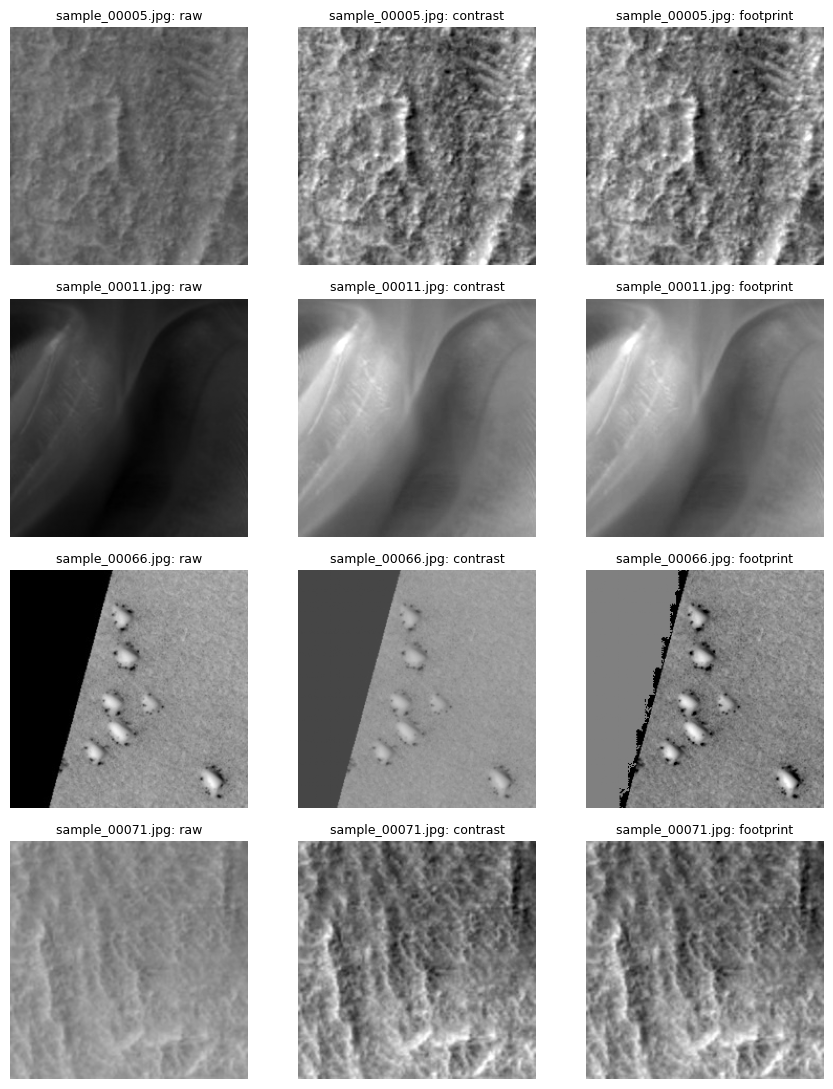

In [5]:
preview = manifest[manifest.split == 'validation'].iloc[[0,1,6,7]]
fig, axes = plt.subplots(4,3,figsize=(9,11))
for i,(_,row) in enumerate(preview.iterrows()):
    raw,_ = CropDataset(pd.DataFrame([row]))[0]
    for j,mode in enumerate(['raw','contrast','footprint']):
        axes[i,j].imshow(preprocess_array(raw[0].numpy(),mode),cmap='gray',vmin=0,vmax=1)
        axes[i,j].set_title(f'{row.filename}: {mode}',fontsize=9)
        axes[i,j].axis('off')
fig.tight_layout()
display(fig)
plt.close(fig)


## Phase 1.1 — My autoencoder
I use five stride-two convolution blocks with channels 16, 32, 64, 96 and 128. Spatial sizes become 114, 57, 29, 15 and 8. A linear layer maps the final feature map to 128 or 256 numbers. The decoder must reconstruct through this vector; there is no skip connection around it.

GroupNorm supports my small batches. Resize-convolution gives explicit output sizes and avoids uneven transposed-convolution overlap. All weights start randomly.

## Phase 1.2 — Loss
v1 uses MSE. For v2 onward I use 0.9 MSE + 0.1 (1 − SSIM), because the baseline smoothed fine texture. SSIM uses an 11 × 11 Gaussian window and direct pixel statistics, without a pretrained network. I report common metrics separately.


In [6]:
import torch
from torch import nn
from torch.nn import functional as F

class ConvAutoencoder(nn.Module):
    """No pretrained weights, external features, or bottleneck bypass."""

    def __init__(self, latent_dim=128):
        super().__init__()
        channels = (1, 16, 32, 64, 96, 128)
        blocks = []
        for cin, cout in zip(channels[:-1], channels[1:]):
            blocks.extend([nn.Conv2d(cin, cout, 3, stride=2, padding=1), nn.GroupNorm(8, cout), nn.SiLU()])
        self.encoder = nn.Sequential(*blocks)
        self.to_latent = nn.Linear(128 * 8 * 8, latent_dim)
        self.from_latent = nn.Linear(latent_dim, 128 * 8 * 8)
        self.decoder = nn.ModuleList()
        for cin, cout in zip((128, 96, 64, 32, 16), (96, 64, 32, 16, 1)):
            layers = [nn.Conv2d(cin, cout, 3, padding=1)]
            layers += [nn.Sigmoid()] if cout == 1 else [nn.GroupNorm(8, cout), nn.SiLU()]
            self.decoder.append(nn.Sequential(*layers))

    def encode(self, x):
        return self.to_latent(self.encoder(x).flatten(1))

    def decode(self, z):
        x = self.from_latent(z).reshape(-1, 128, 8, 8)
        for size, block in zip((15, 29, 57, 114, 227), self.decoder):
            x = block(F.interpolate(x, size=(size, size), mode='bilinear', align_corners=False))
        return x

    def forward(self, x):
        z = self.encode(x)
        return (self.decode(z), z)

def ssim_per_image(x, y):
    """11x11 Gaussian-window SSIM, sigma 1.5, data range 1, valid windows."""
    x, y = (x.float(), y.float())
    coords = torch.arange(11, device=x.device, dtype=x.dtype) - 5
    weights = torch.exp(-coords.square() / (2 * 1.5 ** 2))
    weights = weights / weights.sum()

    def smooth(a):
        a = F.conv2d(a, weights.reshape(1, 1, 1, 11))
        return F.conv2d(a, weights.reshape(1, 1, 11, 1))
    mx, my = (smooth(x), smooth(y))
    vx = (smooth(x * x) - mx * mx).clamp_min(0)
    vy = (smooth(y * y) - my * my).clamp_min(0)
    cov = smooth(x * y) - mx * my
    result = (2 * mx * my + 0.01 ** 2) * (2 * cov + 0.03 ** 2) / ((mx * mx + my * my + 0.01 ** 2) * (vx + vy + 0.03 ** 2))
    return result.mean((1, 2, 3))

def loss_components(x, reconstruction, structural_weight=0.0, gradient_weight=0.0):
    x, reconstruction = (x.float(), reconstruction.float())
    mse = (x - reconstruction).square().mean((1, 2, 3))
    with torch.set_grad_enabled(torch.is_grad_enabled() and structural_weight > 0):
        ssim = ssim_per_image(x, reconstruction)
    dx = x[:, :, :, 1:] - x[:, :, :, :-1] - (reconstruction[:, :, :, 1:] - reconstruction[:, :, :, :-1])
    dy = x[:, :, 1:, :] - x[:, :, :-1, :] - (reconstruction[:, :, 1:, :] - reconstruction[:, :, :-1, :])
    gradient = 0.5 * (dx.abs().mean((1, 2, 3)) + dy.abs().mean((1, 2, 3)))
    loss = (1 - structural_weight) * mse
    if structural_weight:
        loss = loss + structural_weight * (1 - ssim)
    if gradient_weight:
        loss = loss + gradient_weight * gradient
    return {'loss': loss.mean(), 'mse': mse.mean(), 'ssim': ssim.mean(), 'gradient': gradient.mean()}


In [7]:
torch.set_num_threads(4)
for dimension in [128,256]:
    example_model = ConvAutoencoder(dimension)
    with torch.no_grad():
        reconstruction,vector = example_model(torch.zeros(1,1,227,227))
    print(dimension,'dimensions;',sum(p.numel() for p in example_model.parameters()),
          'parameters;',tuple(vector.shape),'latent;',tuple(reconstruction.shape),'output')
del example_model


128 dimensions; 2485249 parameters; (1, 128) latent; (1, 1, 227, 227) output
256 dimensions; 4582529 parameters; (1, 256) latent; (1, 1, 227, 227) output


## Training and saved evidence
Each epoch saves metrics and a fixed reconstruction panel. I select the checkpoint using that run's validation objective. A resumed run must use the same configuration. The plotting and training functions are visible here so this notebook runs without a separate Python package.


In [8]:
from pathlib import Path
import numpy as np
import matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt

def reconstruction_panel(original, reconstruction, path, input_label='Original'):
    original = original.detach().float().cpu().numpy()[:, 0]
    reconstruction = reconstruction.detach().float().cpu().numpy()[:, 0]
    n = len(original)
    fig, axes = plt.subplots(3, n, figsize=(2 * n, 6), squeeze=False)
    error = np.abs(original - reconstruction)
    vmax = max(float(error.max()), 1e-06)
    for j in range(n):
        axes[0, j].imshow(original[j], cmap='gray', vmin=0, vmax=1)
        axes[1, j].imshow(reconstruction[j], cmap='gray', vmin=0, vmax=1)
        im = axes[2, j].imshow(error[j], cmap='inferno', vmin=0, vmax=vmax)
        for i in range(3):
            axes[i, j].set_xticks([])
            axes[i, j].set_yticks([])
    for i, label in enumerate([input_label, 'Reconstruction', 'Absolute error']):
        axes[i, 0].set_ylabel(label)
    fig.colorbar(im, ax=axes[2, :].tolist(), label='Absolute intensity error [0,1]', fraction=0.02)
    fig.savefig(path, dpi=130, bbox_inches='tight')
    plt.close(fig)

def score_plots(frame, calibration, path):
    scores = frame.novelty_score.to_numpy()
    threshold = calibration['threshold']
    fig, axes = plt.subplots(1, 3, figsize=(15, 4))
    for split, g in frame.groupby('split'):
        axes[0].hist(g.novelty_score, bins=50, density=True, histtype='step', label=split)
    axes[0].axvline(threshold, color='red', label='Calibrated fence')
    axes[0].legend(fontsize=8)
    axes[0].set(xlabel='Novelty score (higher = more anomalous)', ylabel='Density', title='Score distributions by split')
    axes[1].plot(np.arange(len(scores)), np.sort(scores))
    axes[1].axhline(threshold, color='red')
    axes[1].axhspan(*calibration['bootstrap_interval_95'], color='red', alpha=0.1)
    axes[1].set(xlabel='Sorted crop index', ylabel='Novelty score', title='Sorted scores and threshold uncertainty')
    axes[2].plot(np.sort(scores), np.arange(1, len(scores) + 1) / len(scores))
    axes[2].axvline(threshold, color='red')
    axes[2].set(xlabel='Novelty score', ylabel='Empirical cumulative fraction', title='Empirical score distribution')
    fig.tight_layout()
    fig.savefig(path, dpi=150)
    plt.close(fig)

def heatmap_panel(original, reconstruction, row, threshold, path):
    original, reconstruction = (np.asarray(original), np.asarray(reconstruction))
    error = np.abs(original - reconstruction)
    fig, axes = plt.subplots(1, 4, figsize=(13, 3.8))
    for ax in axes:
        ax.set_xticks([])
        ax.set_yticks([])
    axes[0].imshow(original, cmap='gray', vmin=0, vmax=1)
    axes[0].set_title('Original')
    axes[1].imshow(reconstruction, cmap='gray', vmin=0, vmax=1)
    axes[1].set_title('Reconstruction')
    im = axes[2].imshow(error, cmap='inferno', vmin=0, vmax=1)
    axes[2].set_title('Absolute error')
    axes[3].imshow(original, cmap='gray', vmin=0, vmax=1)
    axes[3].imshow(error, cmap='inferno', vmin=0, vmax=1, alpha=0.55)
    axes[3].set_title('Error overlay')
    fig.colorbar(im, ax=axes.tolist(), fraction=0.018, pad=0.02, label='Error [0,1]; same scale for all candidates')
    fig.suptitle(f'{row.filename} | {row.source_image_id} | novelty {row.novelty_score:.4f} > {threshold:.4f}\nMaximum absolute error {error.max():.3f}; mean {error.mean():.3f}', fontsize=10)
    fig.savefig(path, dpi=150, bbox_inches='tight')
    plt.close(fig)

def standardized_heatmap_panel(raw, standardized, reconstruction, row, threshold, path, mode):
    error = np.abs(standardized - reconstruction)
    fig, axes = plt.subplots(1, 5, figsize=(15, 4))
    for ax in axes:
        ax.set_xticks([])
        ax.set_yticks([])
    for ax, value, title in zip(axes[:3], [raw, standardized, reconstruction], ['Raw crop', f'Model input: {mode}', 'Reconstruction']):
        ax.imshow(value, cmap='gray', vmin=0, vmax=1)
        ax.set_title(title, fontsize=10)
    im = axes[3].imshow(error, cmap='inferno', vmin=0, vmax=1)
    axes[3].set_title('Model-input error', fontsize=10)
    axes[4].imshow(raw, cmap='gray', vmin=0, vmax=1)
    axes[4].imshow(error, cmap='inferno', vmin=0, vmax=1, alpha=0.55)
    axes[4].set_title('Error on raw scene', fontsize=10)
    fig.colorbar(im, ax=axes.tolist(), fraction=0.016, pad=0.02, label='Standardized-domain error [0,1]')
    fig.suptitle(f'{row.filename} | {row.source_image_id} | novelty {row.novelty_score:.4f} > {threshold:.4f}\nError compares standardized input with reconstruction; not direct forest attribution', fontsize=10)
    fig.savefig(path, dpi=160, bbox_inches='tight')
    plt.close(fig)


In [9]:
import argparse
from dataclasses import asdict, dataclass
from pathlib import Path
import json
import random
import time
import platform
from datetime import datetime
import numpy as np
import pandas as pd
import torch
from torch.utils.data import DataLoader

@dataclass
class TrainConfig:
    version: str = 'v1'
    latent_dim: int = 128
    epochs: int = 15
    batch_size: int = 16
    learning_rate: float = 0.0003
    structural_weight: float = 0.0
    gradient_weight: float = 0.0
    seed: int = 2026
    split_seed: int = 2026
    preprocessing: str = 'raw'
    workers: int = 0
    patience: int = 5
    max_batches: int = 0

def atomic_checkpoint(state, destination):
    """Keep the previous checkpoint intact if serialization fails partway."""
    destination = Path(destination)
    temporary = destination.with_suffix('.tmp.pt')
    torch.save(state, temporary)
    temporary.replace(destination)

def run_training(data_dir, output_dir, config, resume=False):
    if config.epochs < 1 or not 0 <= config.structural_weight <= 1 or config.gradient_weight < 0:
        raise ValueError('Invalid training configuration')
    output_dir = Path(output_dir)
    output_dir.mkdir(parents=True, exist_ok=True)
    last = output_dir / 'last.pt'
    if last.exists() and (not resume):
        raise FileExistsError(f'{last} already exists; choose a new run directory or resume')
    random.seed(config.seed)
    np.random.seed(config.seed)
    torch.manual_seed(config.seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(config.seed)
    torch.set_num_threads(4)
    torch.backends.cudnn.benchmark = False
    torch.backends.cudnn.deterministic = True
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    manifest = load_manifest(data_dir, config.split_seed)
    loaders = {split: DataLoader(CropDataset(manifest[manifest.split == split], config.preprocessing), batch_size=config.batch_size, shuffle=split == 'train', num_workers=config.workers, pin_memory=device.type == 'cuda') for split in ['train', 'validation']}
    model = ConvAutoencoder(config.latent_dim).to(device)
    optimizer = torch.optim.AdamW(model.parameters(), lr=config.learning_rate, weight_decay=0.0001)
    scaler = torch.amp.GradScaler('cuda', enabled=device.type == 'cuda')
    start, best, stale, history = (0, float('inf'), 0, [])
    if resume:
        checkpoint = torch.load(last, map_location=device, weights_only=False)
        prior = checkpoint['config']
        if prior.get('preprocessing', 'raw') != config.preprocessing:
            raise ValueError('Resume mismatch: preprocessing')
        if prior.get('split_seed', prior['seed']) != config.split_seed:
            raise ValueError('Resume mismatch: split_seed')
        for key in ['latent_dim', 'structural_weight', 'gradient_weight', 'seed', 'batch_size', 'learning_rate', 'max_batches']:
            if prior[key] != asdict(config)[key]:
                raise ValueError(f'Resume mismatch: {key}')
        model.load_state_dict(checkpoint['model'])
        optimizer.load_state_dict(checkpoint['optimizer'])
        scaler.load_state_dict(checkpoint['scaler'])
        start, best, stale = (checkpoint['epoch'] + 1, checkpoint['best'], checkpoint['stale'])
        history = checkpoint['history']
        torch.set_rng_state(checkpoint['torch_rng'].cpu())
        if device.type == 'cuda' and checkpoint['cuda_rng'] is not None:
            torch.cuda.set_rng_state_all([s.cpu() for s in checkpoint['cuda_rng']])
        np.random.set_state(checkpoint['numpy_rng'])
        random.setstate(checkpoint['python_rng'])
    manifest.drop(columns='path').to_csv(output_dir / 'split_manifest.csv', index=False)
    config_path = output_dir / 'config.json'
    config_path.write_text(json.dumps(asdict(config), indent=2))
    environment = {'python': platform.python_version(), 'torch': torch.__version__, 'numpy': np.__version__, 'pandas': pd.__version__, 'device': str(device), 'gpu': torch.cuda.get_device_name() if device.type == 'cuda' else None, 'parameters': sum((p.numel() for p in model.parameters())), 'smoke_run': config.max_batches > 0}
    (output_dir / 'environment.json').write_text(json.dumps(environment, indent=2))
    print(json.dumps(environment), flush=True)

    def record_event(event, **details):
        with (output_dir / 'events.jsonl').open('a', encoding='utf-8') as stream:
            stream.write(json.dumps({'time': datetime.now().astimezone().isoformat(), 'event': event, **details}) + '\n')
    record_event('resumed' if resume else 'started', completed_epochs=start, config=asdict(config), device=str(device))
    saved_rng = torch.get_rng_state() if resume else None
    fixed = next(iter(loaders['validation']))[0][:8].to(device)
    if saved_rng is not None:
        torch.set_rng_state(saved_rng)
    for epoch in range(start, config.epochs):
        then = time.perf_counter()
        row = {'epoch': epoch + 1}
        for split, loader in loaders.items():
            training = split == 'train'
            model.train(training)
            sums = dict.fromkeys(['loss', 'mse', 'ssim', 'gradient'], 0.0)
            count = 0
            for batch_index, (x, _) in enumerate(loader):
                if config.max_batches and batch_index >= config.max_batches:
                    break
                x = x.to(device, non_blocking=True)
                with torch.set_grad_enabled(training):
                    with torch.autocast(device_type=device.type, enabled=device.type == 'cuda'):
                        reconstruction, _ = model(x)
                    with torch.autocast(device_type=device.type, enabled=False):
                        metrics = loss_components(x, reconstruction, config.structural_weight, config.gradient_weight)
                    if not torch.isfinite(metrics['loss']):
                        raise RuntimeError('Nonfinite training loss')
                    if training:
                        optimizer.zero_grad(set_to_none=True)
                        scaler.scale(metrics['loss']).backward()
                        scaler.unscale_(optimizer)
                        torch.nn.utils.clip_grad_norm_(model.parameters(), 5.0)
                        scaler.step(optimizer)
                        scaler.update()
                for key, value in metrics.items():
                    sums[key] += float(value.detach()) * len(x)
                count += len(x)
            row.update({split + '_' + key: value / count for key, value in sums.items()})
            row[split + '_images'] = count
        row['seconds'] = time.perf_counter() - then
        history.append(row)
        improved = row['validation_loss'] < best
        best = min(best, row['validation_loss'])
        stale = 0 if improved else stale + 1
        state = {'model': model.state_dict(), 'optimizer': optimizer.state_dict(), 'scaler': scaler.state_dict(), 'config': asdict(config), 'epoch': epoch, 'best': best, 'stale': stale, 'history': history, 'torch_rng': torch.get_rng_state(), 'cuda_rng': torch.cuda.get_rng_state_all() if device.type == 'cuda' else None, 'numpy_rng': np.random.get_state(), 'python_rng': random.getstate()}
        if improved:
            atomic_checkpoint({'model': model.state_dict(), 'config': asdict(config), 'epoch': epoch}, output_dir / 'best.pt')
        atomic_checkpoint(state, last)
        pd.DataFrame(history).to_csv(output_dir / 'history.csv', index=False)
        model.eval()
        with torch.no_grad():
            reconstruction_panel(fixed, model(fixed)[0], output_dir / 'reconstructions_latest.png', input_label='Original' if config.preprocessing == 'raw' else 'Model input: ' + config.preprocessing)
        print(json.dumps(row), flush=True)
        record_event('epoch_completed', **row)
        if stale >= config.patience:
            break
    (output_dir / 'training_status.json').write_text(json.dumps({'status': 'smoke_complete' if config.max_batches else 'complete', 'epochs_completed': len(history), 'best_validation_loss': best}, indent=2))
    record_event('completed', epochs_completed=len(history), best_validation_loss=best)
    return (model, pd.DataFrame(history))


In [10]:
MAIN_RUNS = [{'name': 'v1',
  'latent_dim': 128,
  'structural_weight': 0.0,
  'preprocessing': 'raw',
  'seed': 2026,
  'split_seed': 2026},
 {'name': 'v2',
  'latent_dim': 128,
  'structural_weight': 0.1,
  'preprocessing': 'raw',
  'seed': 2026,
  'split_seed': 2026},
 {'name': 'v3',
  'latent_dim': 256,
  'structural_weight': 0.1,
  'preprocessing': 'raw',
  'seed': 2026,
  'split_seed': 2026},
 {'name': 'v4',
  'latent_dim': 256,
  'structural_weight': 0.1,
  'preprocessing': 'contrast',
  'seed': 2026,
  'split_seed': 2026},
 {'name': 'v5',
  'latent_dim': 256,
  'structural_weight': 0.1,
  'preprocessing': 'footprint',
  'seed': 2026,
  'split_seed': 2026}]
ROBUSTNESS_RUNS = [{'name': 'robust_seed',
  'latent_dim': 256,
  'structural_weight': 0.1,
  'preprocessing': 'raw',
  'seed': 2027,
  'split_seed': 2026},
 {'name': 'robust_split',
  'latent_dim': 256,
  'structural_weight': 0.1,
  'preprocessing': 'raw',
  'seed': 2026,
  'split_seed': 2027},
 {'name': 'improved_seed',
  'latent_dim': 256,
  'structural_weight': 0.1,
  'preprocessing': 'contrast',
  'seed': 2027,
  'split_seed': 2026},
 {'name': 'improved_split',
  'latent_dim': 256,
  'structural_weight': 0.1,
  'preprocessing': 'contrast',
  'seed': 2026,
  'split_seed': 2027}]
RUN_ROBUSTNESS = False  # True reproduces the extra independent runs on a fresh runtime.
run_specs = MAIN_RUNS + (ROBUSTNESS_RUNS if RUN_ROBUSTNESS else [])
for spec in run_specs:
    run = ROOT / 'outputs' / spec['name']
    config = TrainConfig(version=spec['name'],latent_dim=spec['latent_dim'],
                         structural_weight=spec['structural_weight'],
                         preprocessing=spec['preprocessing'],seed=spec['seed'],
                         split_seed=spec['split_seed'],epochs=15)
    if not (run/'training_status.json').exists():
        run_training(DATA,run,config,resume=(run/'last.pt').exists())
    saved = json.loads((run/'config.json').read_text())
    saved.setdefault('split_seed',saved['seed'])  # Early runs used the same seed for both.
    for key in ['latent_dim','structural_weight','seed','split_seed','epochs']:
        assert saved[key] == getattr(config,key), f'{spec["name"]}: mismatched {key}'
    assert saved.get('preprocessing','raw') == config.preprocessing
    assert json.loads((run/'training_status.json').read_text())['status'] == 'complete'
    history = pd.read_csv(run/'history.csv')
    best = history.loc[history.validation_loss.idxmin()]
    print(spec['name'],'| domain:',config.preprocessing,'| epoch:',int(best.epoch),
          '| MSE:',round(best.validation_mse,6),'| SSIM:',round(best.validation_ssim,6))


v1 | domain: raw | epoch: 15 | MSE: 0.002694 | SSIM: 0.661136
v2 | domain: raw | epoch: 15 | MSE: 0.00274 | SSIM: 0.671724
v3 | domain: raw | epoch: 15 | MSE: 0.002599 | SSIM: 0.67381
v4 | domain: contrast | epoch: 11 | MSE: 0.007941 | SSIM: 0.497521
v5 | domain: footprint | epoch: 10 | MSE: 0.008554 | SSIM: 0.471244


## What I changed
| Run | Change | Reason |
|---|---|---|
| v1 | MSE and 128-dimensional vector | Establish the baseline |
| v2 | Add SSIM | Investigate smoothed texture |
| v3 | Increase the vector to 256 | Test additional capacity |
| v4 | Standardize brightness and contrast | Investigate the bright-candidate concentration |
| v5 | Add border-connected-zero treatment | Isolate the additional footprint effect |

The standardized experiments reconstruct different input values. Their MSE is not directly comparable with raw-image v3 MSE.


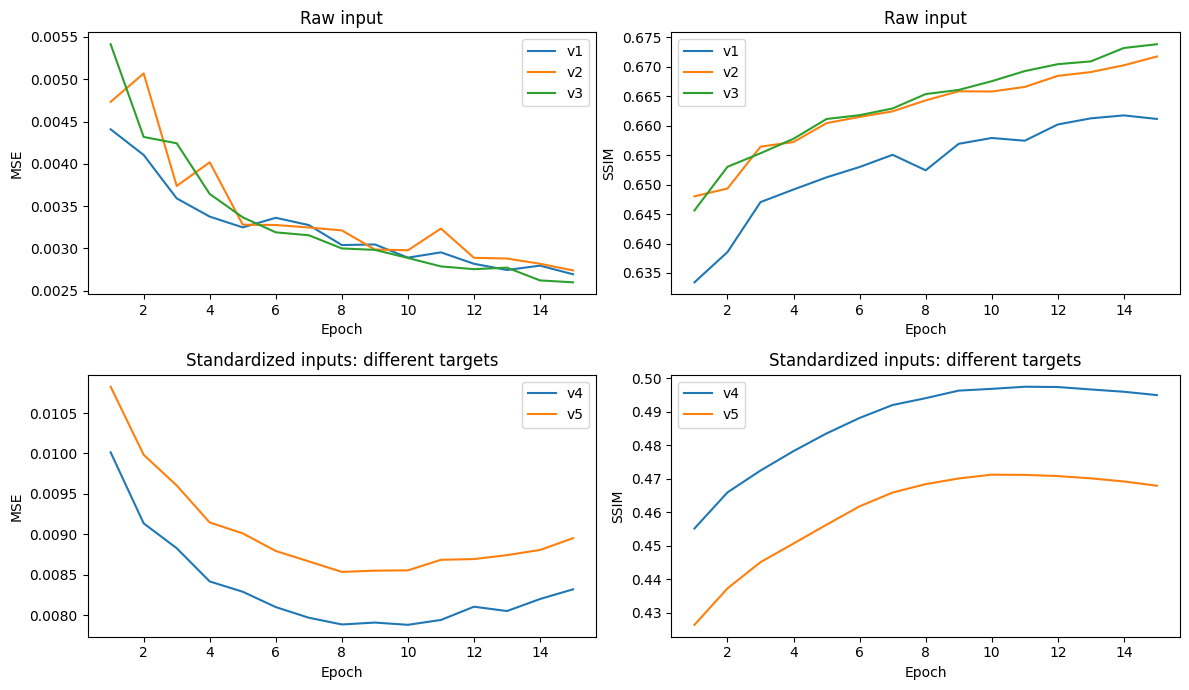

v3


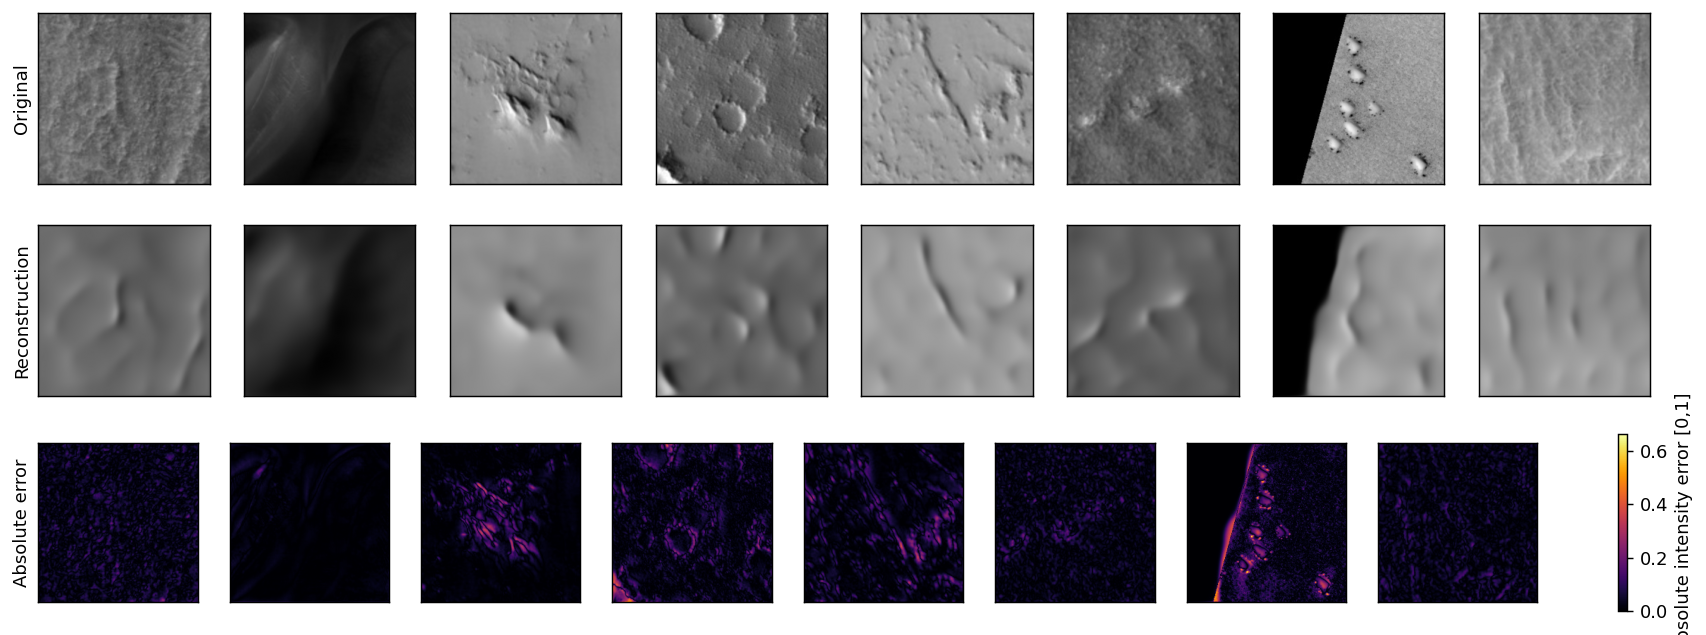

v4


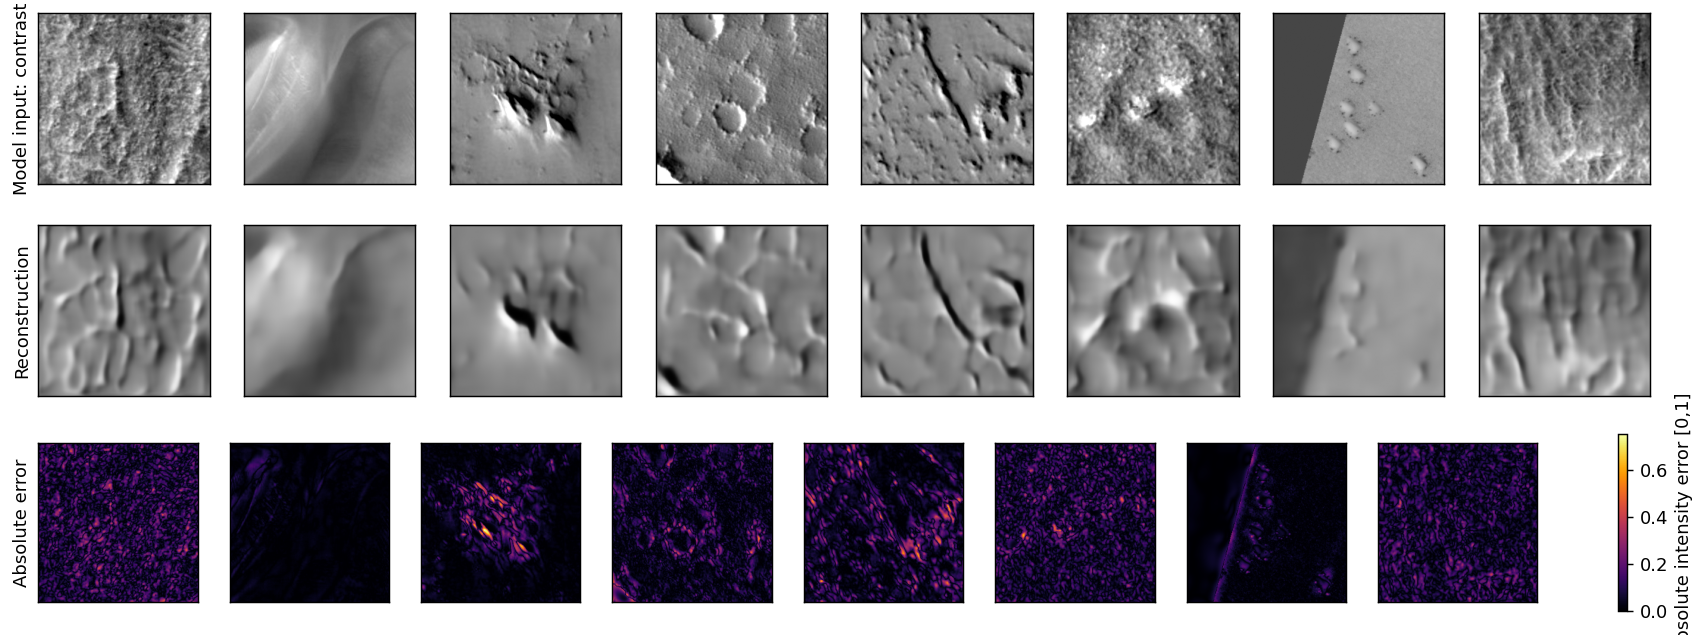

v5


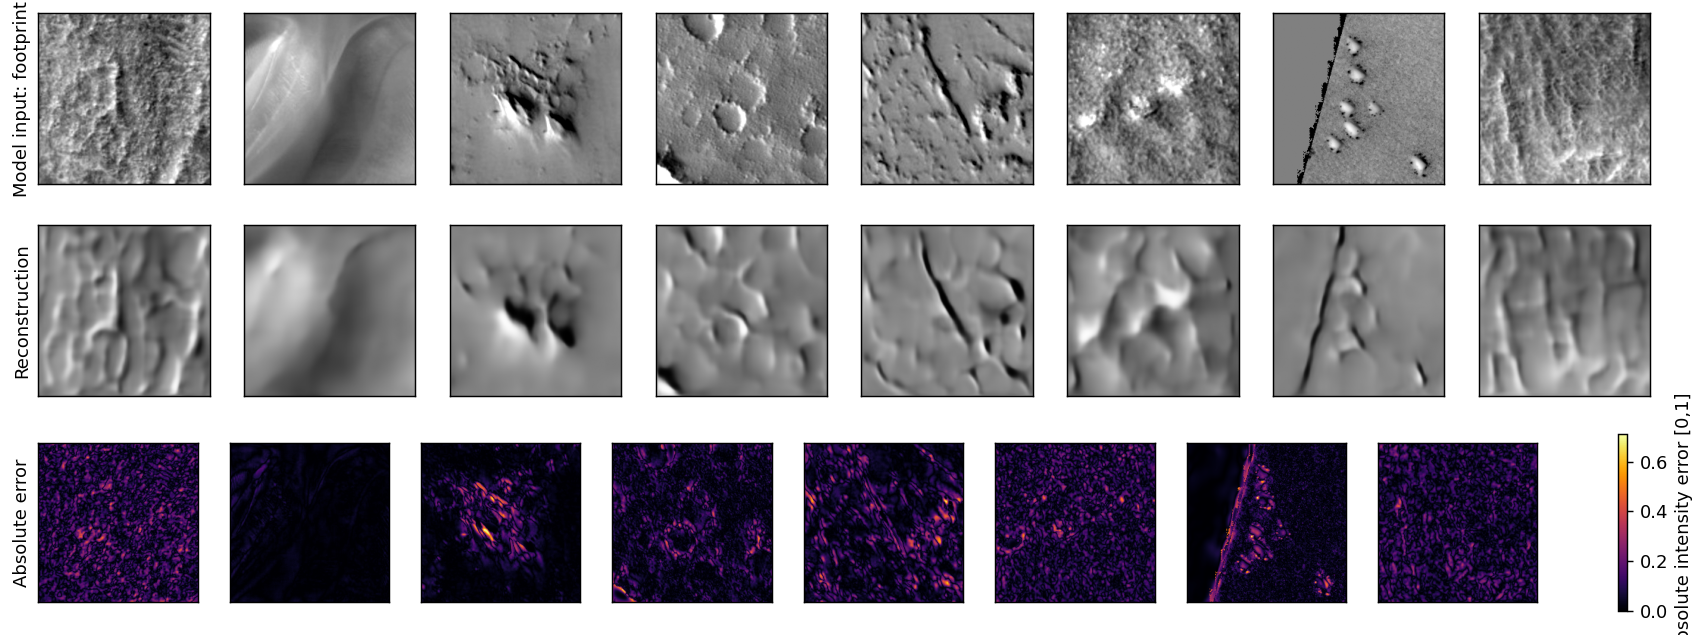

In [11]:
fig,axes = plt.subplots(2,2,figsize=(12,7))
for row,names in enumerate([['v1','v2','v3'],['v4','v5']]):
    for name in names:
        h = pd.read_csv(ROOT/'outputs'/name/'history.csv')
        axes[row,0].plot(h.epoch,h.validation_mse,label=name)
        axes[row,1].plot(h.epoch,h.validation_ssim,label=name)
    for col,metric in enumerate(['MSE','SSIM']):
        axes[row,col].set(xlabel='Epoch',ylabel=metric,
                          title='Raw input' if row == 0 else 'Standardized inputs: different targets')
        axes[row,col].legend()
fig.tight_layout()
display(fig)
plt.close(fig)
for name in ['v3','v4','v5']:
    print(name)
    display(DisplayImage(filename=str(ROOT/'outputs'/name/'reconstructions_latest.png')))


## Phase 2.1 — Isolation Forest on the latent vector
I fit 2,000 trees with 256 samples per tree, only on training latents. My earlier controlled comparison found better forest-seed agreement than at 400 trees. Novelty is negative score_samples: larger means more unusual. I ignore the library's contamination cutoff.

## Phase 2.2 — My statistical boundary
The original adjusted-boxplot threshold exceeded every v1 score. Its histogram was multimodal, so I investigated a distribution model instead of lowering the threshold to obtain five examples.

I fit one to four Gaussian components on calibration scores, choose minimum BIC, and use **T = max(component mean + 3 × component standard deviation)**. The rule puts a boundary beyond each fitted population rather than labelling the entire high-score population anomalous.

I refit model selection in 100 whole-source bootstrap samples. This is conditional uncertainty, not a guaranteed false-positive rate. Correlated crops, unknown contamination and limited model selection remain weaknesses. The same rule applies to every run; zero candidates is allowed.


In [12]:
import numpy as np
from statsmodels.stats.stattools import medcouple

def mixture_fence(scores, seed=2026):
    """Envelope beyond every fitted score population; no contamination fraction."""
    from sklearn.mixture import GaussianMixture
    from threadpoolctl import threadpool_limits
    from scipy.stats import norm
    values = np.asarray(scores, dtype=float)
    if values.ndim != 1 or len(values) < 30 or (not np.isfinite(values).all()) or (values.std() < 1e-08):
        raise ValueError('Need at least 30 finite, nonconstant scores for a mixture')
    with threadpool_limits(limits=2):
        models = [GaussianMixture(n_components=k, n_init=5, random_state=seed, reg_covar=1e-06).fit(values[:, None]) for k in range(1, 5)]
    valid = [m for m in models if m.converged_]
    if not valid:
        raise ValueError('No mixture fit converged')
    best = min(valid, key=lambda m: m.bic(values[:, None]))
    means = best.means_.ravel()
    sigmas = np.sqrt(best.covariances_.ravel())
    threshold = float(np.max(means + 3 * sigmas))
    ordered = np.sort(values)
    cdf = np.sum(best.weights_[None, :] * norm.cdf((ordered[:, None] - means) / sigmas), axis=1)
    n = len(values)
    ks = float(max(np.max(np.arange(1, n + 1) / n - cdf), np.max(cdf - np.arange(n) / n)))
    return {'threshold': threshold, 'method': 'mixture_three_sigma', 'components': best.n_components, 'bic': {str(m.n_components): float(m.bic(values[:, None])) for m in valid}, 'weights': best.weights_.tolist(), 'means': means.tolist(), 'std': sigmas.tolist(), 'calibration_cdf_max_distance': ks, 'fitted_tail_mass': float(np.sum(best.weights_ * norm.sf((threshold - means) / sigmas))), 'component_count_at_search_limit': best.n_components == 4}

def upper_fence(scores):
    values = np.asarray(scores, dtype=float)
    if values.ndim != 1 or len(values) < 8 or (not np.isfinite(values).all()):
        raise ValueError('Need at least 8 finite calibration scores')
    q1, q3 = np.quantile(values, [0.25, 0.75])
    iqr = q3 - q1
    if iqr <= np.finfo(float).eps:
        raise ValueError('Degenerate calibration IQR; investigate representation and scores')
    mc = float(medcouple(values))
    multiplier = 3 if mc >= 0 else 4
    fence = q3 + 1.5 * np.exp(multiplier * mc) * iqr
    return {'threshold': float(fence), 'q1': float(q1), 'q3': float(q3), 'iqr': float(iqr), 'medcouple': mc}

def calibrate(scores, groups, bootstrap=100, seed=2026, method='adjusted_boxplot'):
    values, groups = (np.asarray(scores), np.asarray(groups))
    if values.shape != groups.shape:
        raise ValueError('Scores and groups must have equal shape')
    unique = np.unique(groups)
    if len(unique) < 8:
        raise ValueError('Too few calibration source groups for bootstrap')
    if method not in ('adjusted_boxplot', 'mixture_three_sigma'):
        raise ValueError('Unknown threshold method')
    boundary = upper_fence if method == 'adjusted_boxplot' else lambda x: mixture_fence(x, seed)
    result = boundary(values)
    result['method'] = method
    rng = np.random.default_rng(seed)
    indices = [np.flatnonzero(groups == g) for g in unique]
    thresholds = []
    for _ in range(bootstrap):
        sample = np.concatenate([indices[i] for i in rng.integers(0, len(unique), len(unique))])
        try:
            thresholds.append(boundary(values[sample])['threshold'])
        except ValueError:
            continue
    if len(thresholds) < max(10, bootstrap * 0.8):
        raise ValueError('Too many degenerate bootstrap replicates')
    median = np.median(values)
    mad = np.median(np.abs(values - median))
    q1, q3 = np.quantile(values, [0.25, 0.75])
    result.update({'bootstrap_interval_95': np.quantile(thresholds, [0.025, 0.975]).tolist(), 'bootstrap_thresholds': thresholds, 'bootstrap_valid': len(thresholds), 'calibration_images': len(values), 'calibration_sources': len(unique), 'tukey_comparison': float(q3 + 1.5 * (q3 - q1)), 'mad_comparison': float(median + 3 * 1.4826 * mad), 'interpretation': 'Descriptive distribution-based screening boundary; no nominal false-positive or false-discovery guarantee.'})
    return result

def select_flagged(frame, threshold, limit=5):
    """The limit is only for explanations, never for threshold determination."""
    return frame.loc[frame.novelty_score > threshold].sort_values(['novelty_score', 'filename'], ascending=[False, True]).head(limit)


In [13]:
import argparse
import json
from pathlib import Path
import joblib
import numpy as np
import pandas as pd
import torch
from torch.utils.data import DataLoader
from sklearn.ensemble import IsolationForest
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from scipy.stats import spearmanr

def evaluate(data_dir, run_dir, bootstrap=100, projection=True, allow_smoke=False, method='adjusted_boxplot', trees=400):
    run_dir = Path(run_dir)
    checkpoint = torch.load(run_dir / 'best.pt', map_location='cpu', weights_only=False)
    config = checkpoint['config']
    if method != 'adjusted_boxplot' or trees != 400:
        run_dir = run_dir / (method + (f'_trees{trees}' if trees != 400 else ''))
        run_dir.mkdir(parents=True, exist_ok=True)
    if config['max_batches'] and (not allow_smoke):
        raise ValueError('Smoke checkpoint cannot produce competition results')
    torch.set_num_threads(4)
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    model = ConvAutoencoder(config['latent_dim']).to(device)
    model.load_state_dict(checkpoint['model'])
    model.eval()
    frame = load_manifest(data_dir, config.get('split_seed', config['seed']))
    preprocessing = config.get('preprocessing', 'raw')
    loader = DataLoader(CropDataset(frame, preprocessing), batch_size=config['batch_size'], num_workers=0)
    latents, errors = ([], [])
    with torch.no_grad():
        for x, _ in loader:
            x = x.to(device)
            reconstruction, z = model(x)
            latents.append(z.cpu().numpy())
            errors.extend((x - reconstruction).square().mean((1, 2, 3)).cpu().tolist())
    z = np.concatenate(latents)
    np.save(run_dir / 'latents.npy', z)
    np.save(run_dir / 'latent_filenames.npy', frame.filename.to_numpy(dtype=str))
    train = frame.split.eq('train').to_numpy()
    calibration_mask = frame.split.eq('calibration').to_numpy()
    forest = IsolationForest(n_estimators=trees, max_samples=256, contamination='auto', random_state=config['seed'], n_jobs=2)
    forest.fit(z[train])
    frame['novelty_score'] = -forest.score_samples(z)
    frame['reconstruction_mse'] = errors
    calibration = calibrate(frame.loc[calibration_mask, 'novelty_score'], frame.loc[calibration_mask, 'source_image_id'], bootstrap, config['seed'], method)
    frame['flagged'] = frame.novelty_score > calibration['threshold']
    boot = np.asarray(calibration['bootstrap_thresholds'])
    frame['threshold_bootstrap_flag_frequency'] = (frame.novelty_score.to_numpy()[:, None] > boot[None, :]).mean(1)
    stability = []
    for seed in (config['seed'] + 1, config['seed'] + 2):
        other = IsolationForest(n_estimators=trees, max_samples=256, contamination='auto', random_state=seed, n_jobs=2).fit(z[train])
        other_scores = -other.score_samples(z)
        boundary = (upper_fence(other_scores[calibration_mask]) if method == 'adjusted_boxplot' else mixture_fence(other_scores[calibration_mask], config['seed']))['threshold']
        other_flags = other_scores > boundary
        primary_flags = frame.flagged.to_numpy()
        union = np.count_nonzero(primary_flags | other_flags)
        stability.append({'seed': seed, 'spearman': float(spearmanr(frame.novelty_score, other_scores).statistic), 'flag_count': int(other_flags.sum()), 'threshold': boundary, 'flag_jaccard': float(np.count_nonzero(primary_flags & other_flags) / union) if union else None})
    covariance = np.cov(z[train], rowvar=False)
    eigenvalues = np.linalg.eigvalsh(covariance).clip(0)
    proportions = eigenvalues / max(eigenvalues.sum(), 1e-12)
    effective_rank = float(np.exp(-np.sum(proportions * np.log(proportions + 1e-12))))
    diagnostics = {'effective_rank': effective_rank, 'latent_dimensions': z.shape[1], 'latent_variance': z[train].var(0).tolist(), 'forest_seed_stability': stability, 'flagged_total': int(frame.flagged.sum()), 'flagged_by_split': frame.groupby('split').flagged.agg(['sum', 'count', 'mean']).to_dict(), 'smoke_checkpoint': bool(config['max_batches']), 'threshold_exceeds_maximum': bool(calibration['threshold'] > frame.novelty_score.max())}
    diagnostics['n_estimators'] = trees
    diagnostics['preprocessing'] = preprocessing
    diagnostics['reconstruction_domain'] = 'raw intensity / 255' if preprocessing == 'raw' else preprocessing + ' standardized input'
    if method == 'mixture_three_sigma':
        from scipy.stats import norm
        means = np.array(calibration['means'])
        std = np.array(calibration['std'])
        weights = np.array(calibration['weights'])
        heldout = np.sort(frame.loc[frame.split.eq('validation'), 'novelty_score'])
        cdf = np.sum(weights * norm.cdf((heldout[:, None] - means) / std), axis=1)
        n = len(heldout)
        diagnostics['validation_cdf_max_distance'] = float(max(np.max(np.arange(1, n + 1) / n - cdf), np.max(cdf - np.arange(n) / n)))
        diagnostics['validation_cdf_note'] = 'Descriptive held-out density-fit diagnostic; correlated sources preclude an ordinary IID KS p-value.'
    (run_dir / 'calibration.json').write_text(json.dumps(calibration, indent=2))
    (run_dir / 'diagnostics.json').write_text(json.dumps(diagnostics, indent=2))
    frame.drop(columns='path').to_csv(run_dir / 'novelty_scores.csv', index=False)
    joblib.dump(forest, run_dir / 'isolation_forest.joblib')
    score_plots(frame, calibration, run_dir / 'score_distribution.png')
    source_summary = frame.groupby('source_image_id').agg(crops=('filename', 'size'), flagged=('flagged', 'sum'), mean_novelty=('novelty_score', 'mean'), latitude=('latitude', 'first'), longitude=('longitude', 'first'), sun_angle=('sun_angle', 'first'), season=('season', 'first'), resolution=('resolution', 'first'))
    source_summary['flag_rate'] = source_summary.flagged / source_summary.crops
    source_summary.to_csv(run_dir / 'source_summary.csv')
    for column in ('season', 'resolution', 'longitude'):
        crop_summary = frame.groupby(column).flagged.agg(['count', 'sum', 'mean'])
        equal_source = source_summary.groupby(column).flag_rate.mean()
        crop_summary['equal_source_mean_flag_rate'] = equal_source
        crop_summary.to_csv(run_dir / f'metadata_{column}.csv')
    selected = select_flagged(frame, calibration['threshold'])
    selected.drop(columns='path').to_csv(run_dir / 'selected_for_interpretation.csv', index=False)
    for _, row in selected.iterrows():
        x, _ = CropDataset(pd.DataFrame([row]), preprocessing)[0]
        with torch.no_grad():
            rec = model(x[None].to(device))[0][0, 0].cpu().numpy()
        if preprocessing == 'raw':
            heatmap_panel(x[0].numpy(), rec, row, calibration['threshold'], run_dir / f'heatmap_{Path(row.filename).stem}.png')
        else:
            raw, _ = CropDataset(pd.DataFrame([row]))[0]
            standardized_heatmap_panel(raw[0].numpy(), x[0].numpy(), rec, row, calibration['threshold'], run_dir / f'heatmap_{Path(row.filename).stem}.png', preprocessing)
    if projection:
        import matplotlib.pyplot as plt
        scale = z[train].std(0).clip(1e-06)
        standardized = (z - z[train].mean(0)) / scale
        reduced = PCA(n_components=min(50, z.shape[1]), random_state=config['seed']).fit_transform(standardized)
        for perplexity in (30, 70):
            xy = TSNE(n_components=2, perplexity=perplexity, init='pca', learning_rate='auto', random_state=config['seed'], max_iter=1000).fit_transform(reduced)
            pd.DataFrame({'filename': frame.filename, 'x': xy[:, 0], 'y': xy[:, 1]}).to_csv(run_dir / f'tsne_{perplexity}.csv', index=False)
            fig, axes = plt.subplots(1, 3, figsize=(15, 4))
            for ax, values, title in zip(axes, [frame.novelty_score, frame.sun_angle, pd.Categorical(frame.source_image_id).codes], ['Novelty score', 'Sun angle as supplied', 'Source ID (categorical colors)']):
                points = ax.scatter(xy[:, 0], xy[:, 1], c=values, s=3, cmap='viridis', rasterized=True)
                fig.colorbar(points, ax=ax)
                ax.set_title(title)
                ax.set_xticks([])
                ax.set_yticks([])
            fig.suptitle(f't-SNE perplexity {perplexity}; qualitative projection, not geological labels')
            fig.tight_layout()
            fig.savefig(run_dir / f'tsne_{perplexity}.png', dpi=160)
            plt.close(fig)
    print(json.dumps({k: v for k, v in diagnostics.items() if k != 'latent_variance'}, indent=2), flush=True)
    return (frame, calibration, diagnostics)


In [14]:
analysis_name = 'mixture_three_sigma_trees2000'
for spec in MAIN_RUNS + ROBUSTNESS_RUNS:
    run = ROOT/'outputs'/spec['name']
    if not (run/'training_status.json').exists():
        print(spec['name'],': optional repeat absent from this runtime')
        continue
    analysis = run/analysis_name
    if not (analysis/'selected_for_interpretation.csv').exists():
        evaluate(DATA,run,bootstrap=100,projection=False,
                 method='mixture_three_sigma',trees=2000)
    d = json.loads((analysis/'diagnostics.json').read_text())
    c = json.loads((analysis/'calibration.json').read_text())
    print(spec['name'],'| threshold:',round(c['threshold'],6),'| flags:',d['flagged_total'])


v1 | threshold: 0.540828 | flags: 20
v2 | threshold: 0.533417 | flags: 9
v3 | threshold: 0.542471 | flags: 17
v4 | threshold: 0.473769 | flags: 24
v5 | threshold: 0.460566 | flags: 42
robust_seed | threshold: 0.519261 | flags: 6
robust_split | threshold: 0.519878 | flags: 5
improved_seed | threshold: 0.470193 | flags: 11
improved_split | threshold: 0.479434 | flags: 10


## My selection after the checks

I retain v3 as the screening reference. v4 and v5 reduce a specified brightness nuisance, but their minimum forest-seed flag overlaps fall from 0.667 for v3 to 0.467 and 0.227. All five leading v4 examples contain conspicuous black strips or borders, and the v5 exact-zero mask leaves near-black edge fragments. That evidence does not support replacing the reference with a more reliable geological detector. v3 itself remains brightness-confounded and unstable across independent training runs; I do not present its candidates as confirmed anomalies.

For v4, changing initialization gives flag-set Jaccard 0.207 and full-ranking correlation 0.867; changing the source split gives 0.360 and 0.866. The three contrast runs flag 24, 11 and 10 crops, with 4 in their intersection. On 1,253 crops held out from both source partitions, rank correlation is 0.897. For raw v3, the corresponding initialization/split Jaccards remain 0.150/0.294, with zero crops flagged in all three raw runs. These are limited sensitivity checks, not detection accuracy. Initialization repeats change both encoder and forest seeds; separate forest-only repeats isolate detector randomness.

{'threshold': 0.542470711355725,
 'method': 'mixture_three_sigma',
 'components': 4,
 'bic': {'1': -5767.229815429284,
  '2': -7086.335157900152,
  '3': -7282.352476131511,
  '4': -7283.200707504232},
 'weights': [0.49083650711401383,
  0.22636562196034749,
  0.09861652470257883,
  0.18418134622305987],
 'means': [0.3888785499310877,
  0.4904299176009934,
  0.43882286330132747,
  0.4102264483850351],
 'std': [0.007065795799737778,
  0.017346931251577186,
  0.012773538501546973,
  0.01074626605159847],
 'calibration_cdf_max_distance': 0.011652845340767937,
 'fitted_tail_mass': 0.0003055705075130169,
 'component_count_at_search_limit': True,
 'bootstrap_interval_95': [0.5352300825689355, 0.5504698972900013],
 'bootstrap_valid': 100,
 'calibration_images': 1655,
 'calibration_sources': 27,
 'tukey_comparison': 0.5348369819747809,
 'mad_comparison': 0.4726098613004698,
 'interpretation': 'Descriptive distribution-based screening boundary; no nominal false-positive or false-discovery guaran

,count,sum,mean
split,,,
calibration,1655,1,0.000604
train,7101,14,0.001972
validation,1666,2,0.001200


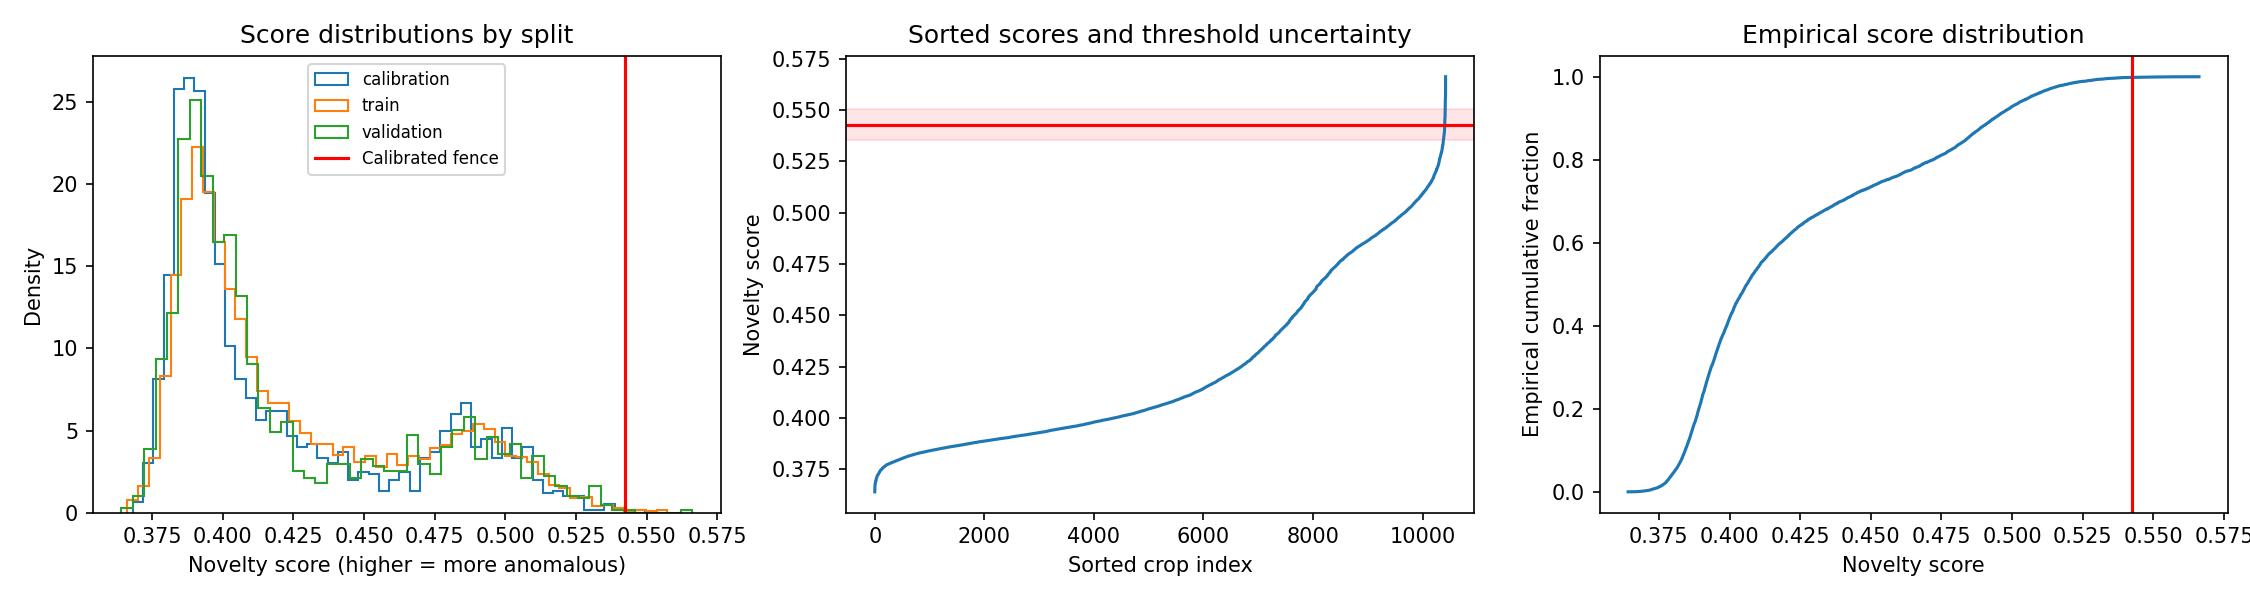

In [15]:
RECORDED_SELECTION = {'run': 'v3',
 'analysis': 'mixture_three_sigma_trees2000',
 'status': 'Complete',
 'recorded_at': '2026-09-16T23:56:16+05:30'}
RUN = ROOT/'outputs'/RECORDED_SELECTION['run']
ANALYSIS = RUN/analysis_name
scored = pd.read_csv(ANALYSIS/'novelty_scores.csv')
calibration = json.loads((ANALYSIS/'calibration.json').read_text())
diagnostics = json.loads((ANALYSIS/'diagnostics.json').read_text())
display({k:v for k,v in calibration.items() if k != 'bootstrap_thresholds'})
display(scored.groupby('split').flagged.agg(['count','sum','mean']))
display(DisplayImage(filename=str(ANALYSIS/'score_distribution.png')))


## Phase 1.3 — Looking at the latent space
PCA and t-SNE are only for plotting; the forest receives the full vector. I compare two perplexities and color by novelty, sun angle and source. Branches are not verified geological classes, and effective rank is not a class count.


In [16]:
"""Generate t-SNE diagnostics from existing latents without rerunning calibration."""
import argparse
from pathlib import Path
import numpy as np
import pandas as pd
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from threadpoolctl import threadpool_limits
import matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt

def project(directory):
    z = np.load(directory / 'latents.npy')
    frame = pd.read_csv(directory / 'novelty_scores.csv')
    assert np.array_equal(np.load(directory / 'latent_filenames.npy'), frame.filename)
    train = frame.split.eq('train').to_numpy()
    scaled = (z - z[train].mean(0)) / z[train].std(0).clip(1e-06)
    with threadpool_limits(limits=2):
        reduced = PCA(n_components=min(50, z.shape[1]), random_state=2026).fit_transform(scaled)
        for perplexity in [30, 70]:
            xy = TSNE(perplexity=perplexity, max_iter=1000, init='pca', learning_rate='auto', random_state=2026, n_jobs=2).fit_transform(reduced)
            pd.DataFrame({'filename': frame.filename, 'x': xy[:, 0], 'y': xy[:, 1]}).to_csv(directory / f'tsne_{perplexity}.csv', index=False)
            fig, axes = plt.subplots(1, 3, figsize=(15, 4.6))
            for ax, values, label in zip(axes[:2], [frame.novelty_score, frame.sun_angle], ['Novelty score', 'Sun angle as supplied']):
                points = ax.scatter(xy[:, 0], xy[:, 1], c=values, s=3, cmap='viridis', rasterized=True)
                fig.colorbar(points, ax=ax, shrink=0.8)
                ax.set_title(label)
            largest = frame.source_image_id.value_counts().head(5).index
            axes[2].scatter(xy[:, 0], xy[:, 1], s=2, c='lightgray', label='Other sources')
            for i, source in enumerate(largest):
                mask = frame.source_image_id.eq(source)
                axes[2].scatter(xy[mask, 0], xy[mask, 1], s=4, color=plt.get_cmap('tab10')(i), label=source)
            axes[2].legend(fontsize=7, loc='best')
            axes[2].set_title('Five largest source groups')
            for ax in axes:
                ax.set_xticks([])
                ax.set_yticks([])
            fig.suptitle(f't-SNE, perplexity {perplexity}: qualitative diagnostic, not confirmed terrain classes')
            fig.tight_layout()
            fig.savefig(directory / f'tsne_{perplexity}.png', dpi=160)
            plt.close(fig)
            print(f'Completed t-SNE {perplexity}', flush=True)


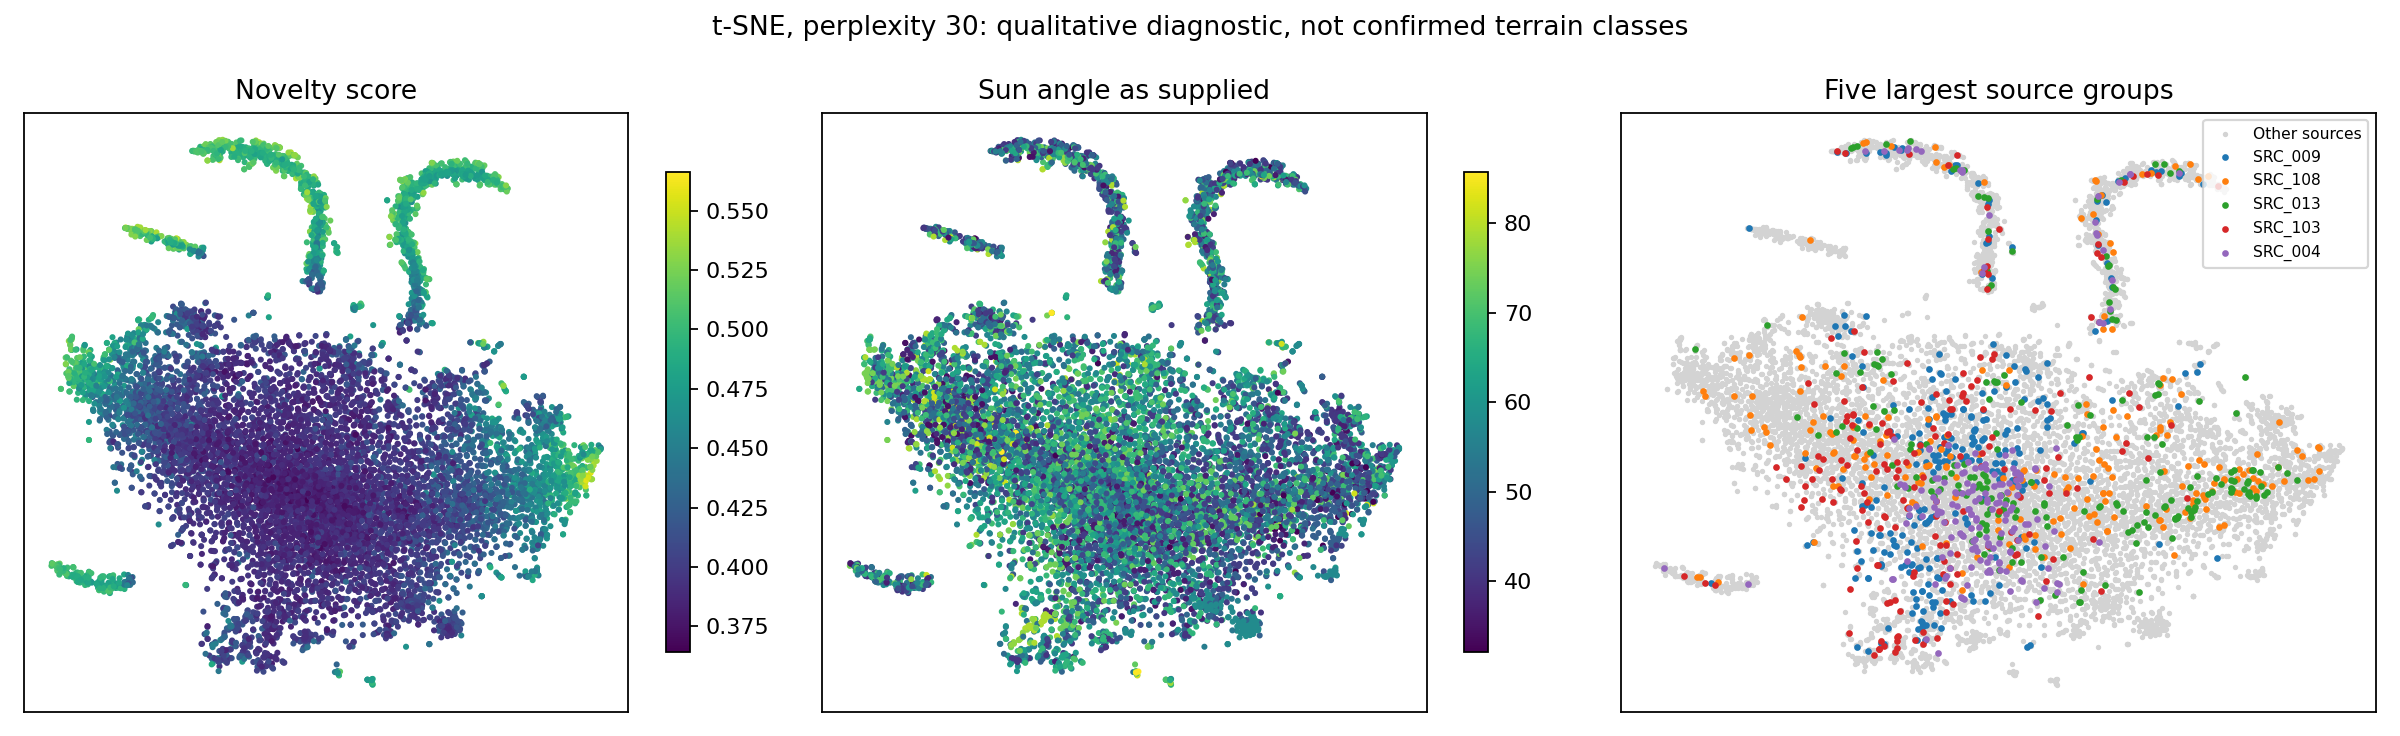

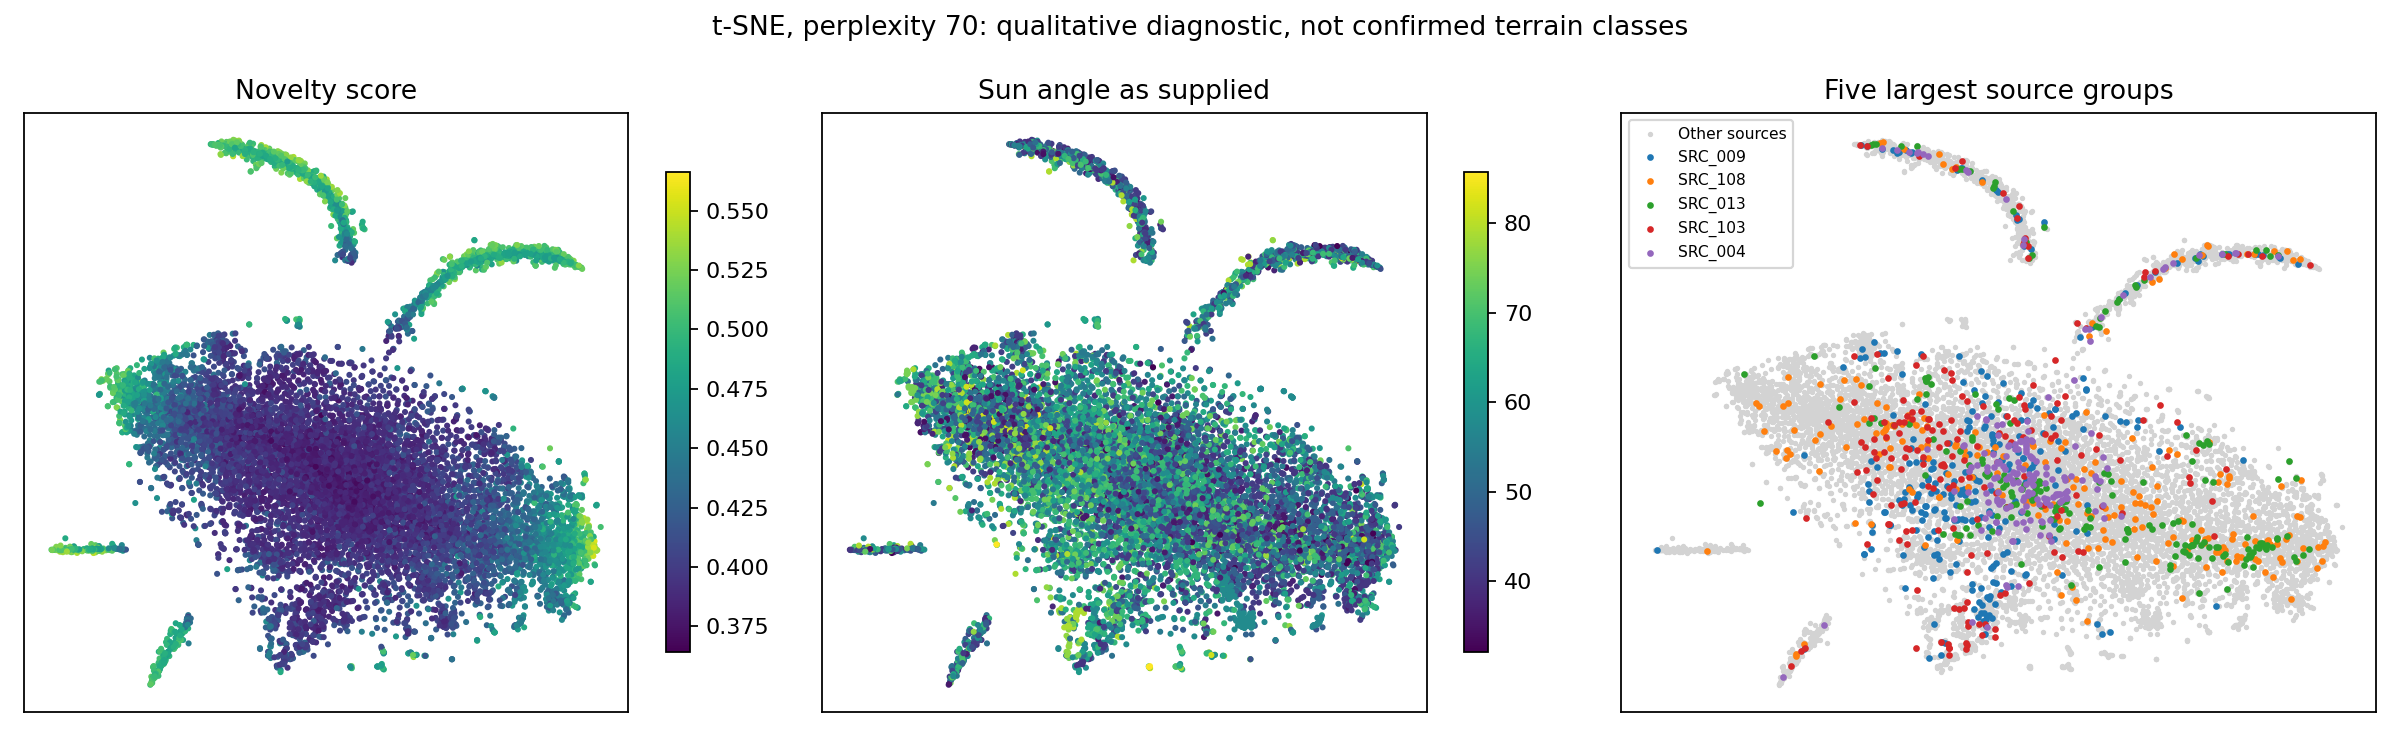

Effective rank: 31.525835123693962 of 256


In [17]:
if not all((ANALYSIS/f'tsne_{p}.png').exists() for p in [30,70]):
    project(ANALYSIS)
for p in [30,70]:
    display(DisplayImage(filename=str(ANALYSIS/f'tsne_{p}.png')))
print('Effective rank:',diagnostics['effective_rank'],'of',diagnostics['latent_dimensions'])


## Did the improvements reduce the problem?
I report both full-ranking correlation and overlap of the flagged sets. A high correlation can conceal disagreement in the extreme tail. I also hold each fitted forest and cutoff fixed while applying 0.8 × x + 0.1 outside the inferred black border. Keeping the footprint fixed simulates exposure changes rather than changing crop support. This is a nuisance-sensitivity check, not labelled detection accuracy.


In [18]:
"""Compare saved experiments without inventing hidden-label accuracy."""
from pathlib import Path
import argparse, json
import numpy as np
import pandas as pd
from scipy.stats import spearmanr
import matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt

def summarize(root):
    output = root / 'outputs' / 'comparison'
    output.mkdir(exist_ok=True)
    rows = []
    frames = {}
    for name in ['v1', 'v2', 'v3', 'robust_seed', 'robust_split', 'v4', 'v5', 'improved_seed', 'improved_split']:
        run = root / 'outputs' / name
        if not (run / 'training_status.json').exists():
            continue
        config = json.loads((run / 'config.json').read_text())
        history = pd.read_csv(run / 'history.csv')
        best = history.loc[history.validation_loss.idxmin()]
        row = {'run': name, 'latent_dim': config['latent_dim'], 'ssim_weight': config['structural_weight'], 'seed': config['seed'], 'split_seed': config.get('split_seed', config['seed']), 'best_epoch': int(best.epoch), 'validation_mse': best.validation_mse, 'validation_ssim': best.validation_ssim, 'validation_gradient': best.validation_gradient, 'training_seconds': history.seconds.sum()}
        row['input_domain'] = config.get('preprocessing', 'raw')
        analysis = run / 'mixture_three_sigma_trees2000'
        if not (analysis / 'diagnostics.json').exists():
            analysis = run / 'mixture_three_sigma'
        if (analysis / 'diagnostics.json').exists():
            diagnostics = json.loads((analysis / 'diagnostics.json').read_text())
            calibration = json.loads((analysis / 'calibration.json').read_text())
            row['trees'] = diagnostics.get('n_estimators', 400)
            row.update({'effective_rank': diagnostics['effective_rank'], 'threshold': calibration['threshold'], 'threshold_low': calibration['bootstrap_interval_95'][0], 'threshold_high': calibration['bootstrap_interval_95'][1], 'flagged': diagnostics['flagged_total'], 'validation_cdf_distance': diagnostics['validation_cdf_max_distance'], 'components': calibration['components'], 'forest_min_spearman': min((x['spearman'] for x in diagnostics['forest_seed_stability']))})
            frames[name] = pd.read_csv(analysis / 'novelty_scores.csv').set_index('filename')
        rows.append(row)
    table = pd.DataFrame(rows)
    table.to_csv(output / 'experiments.csv', index=False)
    pairs = []
    for i, left in enumerate(frames):
        for right in list(frames)[i + 1:]:
            a, b = frames[left].align(frames[right], join='inner', axis=0)
            union = np.count_nonzero(a.flagged | b.flagged)
            heldout = (a.split != 'train') & (b.split != 'train')
            pairs.append({'left': left, 'right': right, 'spearman_all': float(spearmanr(a.novelty_score, b.novelty_score).statistic), 'flag_jaccard': float(np.count_nonzero(a.flagged & b.flagged) / union) if union else None, 'common_heldout_images': int(heldout.sum()), 'spearman_common_heldout': float(spearmanr(a.loc[heldout, 'novelty_score'], b.loc[heldout, 'novelty_score']).statistic)})
    pd.DataFrame(pairs).to_csv(output / 'run_stability.csv', index=False)
    statistics_path = root / 'outputs/audit/image_statistics.csv'
    stats = pd.read_csv(statistics_path).set_index('filename') if statistics_path.exists() else None
    confounds = []
    for name, frame in frames.items():
        if stats is None:
            continue
        joined = frame.join(stats)
        total = ((joined.novelty_score - joined.novelty_score.mean()) ** 2).sum()
        source_means = joined.groupby('source_image_id').novelty_score.transform('mean')
        explained = float(((source_means - joined.novelty_score.mean()) ** 2).sum() / total)
        row = {'run': name, 'source_between_group_variance_fraction': explained}
        for c in ['mean', 'std', 'zero_fraction', 'sun_angle', 'latitude']:
            row['spearman_' + c] = float(spearmanr(joined[c], joined.novelty_score).statistic)
        confounds.append(row)
    if confounds:
        pd.DataFrame(confounds).to_csv(output / 'confounds.csv', index=False)
    fig, axes = plt.subplots(1, 3, figsize=(13, 3.7))
    for name in ['v1', 'v2', 'v3']:
        run = root / 'outputs' / name
        if not (run / 'history.csv').exists():
            continue
        history = pd.read_csv(run / 'history.csv')
        for ax, metric in zip(axes, ['mse', 'ssim', 'gradient']):
            ax.plot(history.epoch, history['validation_' + metric], label=name)
    for ax, metric in zip(axes, ['MSE (lower better)', 'SSIM (higher better)', 'Gradient error (lower better)']):
        ax.set(xlabel='Epoch', ylabel=metric)
        ax.legend()
    fig.tight_layout()
    fig.savefig(output / 'validation_curves.png', dpi=170)
    plt.close(fig)
    print(table.to_string(index=False))
    print(pd.DataFrame(pairs).to_string(index=False))
    print(pd.DataFrame(confounds).to_string(index=False))


In [19]:
summarize(ROOT)
display(pd.read_csv(ROOT/'outputs/comparison/experiments.csv'))
display(pd.read_csv(ROOT/'outputs/comparison/run_stability.csv'))


           run  latent_dim  ssim_weight  seed  split_seed  best_epoch  validation_mse  validation_ssim  validation_gradient  training_seconds input_domain  trees  effective_rank  threshold  threshold_low  threshold_high  flagged  validation_cdf_distance  components  forest_min_spearman
            v1         128          0.0  2026        2026          15        0.002694         0.661136             0.014007        515.429472          raw   2000       12.167152   0.540828       0.532605        0.555416       20                 0.050172           3             0.995350
            v2         128          0.1  2026        2026          15        0.002740         0.671724             0.014001      12137.604974          raw   2000       27.066506   0.533417       0.529221        0.538640        9                 0.073931           4             0.994658
            v3         256          0.1  2026        2026          15        0.002599         0.673810             0.013958        708.2515

,run,latent_dim,ssim_weight,seed,split_seed,best_epoch,validation_mse,validation_ssim,validation_gradient,training_seconds,input_domain,trees,effective_rank,threshold,threshold_low,threshold_high,flagged,validation_cdf_distance,components,forest_min_spearman
0,v1,128,0.0,2026,2026,15,0.002694,0.661136,0.014007,515.429472,raw,2000,12.167152,0.540828,0.532605,0.555416,20,0.050172,3,0.995350
1,v2,128,0.1,2026,2026,15,0.002740,0.671724,0.014001,12137.604974,raw,2000,27.066506,0.533417,0.529221,0.538640,9,0.073931,4,0.994658
2,v3,256,0.1,2026,2026,15,0.002599,0.673810,0.013958,708.251591,raw,2000,31.525835,0.542471,0.535230,0.550470,17,0.059654,4,0.994581
3,robust_seed,256,0.1,2027,2026,15,0.002589,0.676677,0.013889,8069.849382,raw,2000,47.129822,0.519261,0.515982,0.522855,6,0.055369,3,0.991669
4,robust_split,256,0.1,2026,2027,14,0.002351,0.698485,0.013199,8101.657692,raw,2000,43.850979,0.519878,0.515344,0.525659,5,0.082083,3,0.991753
5,v4,256,0.1,2026,2026,11,0.007941,0.497521,0.026629,892.174724,contrast,2000,171.302398,0.473769,0.471401,0.476601,24,0.086109,2,0.958043
6,v5,256,0.1,2026,2026,10,0.008554,0.471244,0.028705,1031.704453,footprint,2000,193.021147,0.460566,0.459168,0.464235,42,0.110778,1,0.926940
7,improved_seed,256,0.1,2027,2026,12,0.007757,0.502404,0.026570,575.861716,contrast,2000,175.675983,0.470193,0.467643,0.473727,11,0.082721,2,0.945415
8,improved_split,256,0.1,2026,2027,11,0.006724,0.534854,0.024253,957.210550,contrast,2000,175.656496,0.479434,0.474419,0.483731,10,0.057465,2,0.958042


,left,right,spearman_all,flag_jaccard,common_heldout_images,spearman_common_heldout
0,v1,v2,0.967512,0.260870,3321,0.961782
1,v1,v3,0.959513,0.370370,3321,0.950862
2,v1,robust_seed,0.935165,0.083333,3321,0.920148
3,v1,robust_split,0.941612,0.250000,1253,0.939272
4,v1,v4,0.645302,0.000000,3321,0.675767
5,v1,v5,0.477498,0.000000,3321,0.526909
6,v1,improved_seed,0.607044,0.000000,3321,0.643218
7,v1,improved_split,0.635409,0.000000,1253,0.659229
8,v2,v3,0.976219,0.181818,3321,0.972956
9,v2,robust_seed,0.942994,0.000000,3321,0.936246


In [20]:
"""Hold the fitted forest/cutoff fixed while perturbing validation illumination."""
from pathlib import Path
import sys, argparse, json
import numpy as np
import pandas as pd
import torch, joblib

def measure(root, runs):
    torch.set_num_threads(2)
    device = 'cuda' if torch.cuda.is_available() else 'cpu'
    rows = []
    for name in runs:
        run = root / 'outputs' / name
        analysis = run / 'mixture_three_sigma_trees2000'
        if not (analysis / 'diagnostics.json').exists():
            continue
        checkpoint = torch.load(run / 'best.pt', map_location='cpu', weights_only=False)
        config = checkpoint['config']
        mode = config.get('preprocessing', 'raw')
        frame = load_manifest(root / 'data', config.get('split_seed', config['seed']))
        frame = frame[frame.split == 'validation'].sample(n=min(512, int((frame.split == 'validation').sum())), random_state=42).reset_index(drop=True)
        model = ConvAutoencoder(config['latent_dim']).to(device)
        model.load_state_dict(checkpoint['model'])
        model.eval()
        original = []
        altered = []
        for x, _ in CropDataset(frame):
            a = x[0].numpy()
            mask = border_zero_mask(a)
            b = 0.8 * a + 0.1
            b[mask] = 0
            original.append(preprocess_array(a, mode))
            altered.append(preprocess_array(b, mode))

        def encode(arrays):
            outputs = []
            with torch.no_grad():
                for i in range(0, len(arrays), 16):
                    batch = torch.from_numpy(np.stack(arrays[i:i + 16])[:, None]).to(device)
                    outputs.append(model.encode(batch).cpu().numpy())
            return np.concatenate(outputs)
        z0, z1 = (encode(original), encode(altered))
        forest = joblib.load(analysis / 'isolation_forest.joblib')
        s0, s1 = (-forest.score_samples(z0), -forest.score_samples(z1))
        threshold = json.loads((analysis / 'calibration.json').read_text())['threshold']
        delta = np.abs(s1 - s0)
        result = {'run': name, 'preprocessing': mode, 'validation_crops': len(frame), 'gain': 0.8, 'offset': 0.1, 'median_absolute_score_change': float(np.median(delta)), 'p95_absolute_score_change': float(np.quantile(delta, 0.95)), 'mean_input_absolute_change': float(np.abs(np.array(original) - np.array(altered)).mean()), 'median_relative_latent_change': float(np.median(np.linalg.norm(z1 - z0, axis=1) / np.maximum(np.linalg.norm(z0, axis=1), 1e-08))), 'flag_flips': int(np.count_nonzero((s0 > threshold) != (s1 > threshold))), 'original_flags': int((s0 > threshold).sum()), 'perturbed_flags': int((s1 > threshold).sum())}
        rows.append(result)
        pd.DataFrame({'filename': frame.filename, 'original_score': s0, 'perturbed_score': s1, 'absolute_change': delta}).to_csv(analysis / 'photometric_sensitivity.csv', index=False)
    table = pd.DataFrame(rows)
    out = root / 'outputs/comparison'
    out.mkdir(exist_ok=True, parents=True)
    table.to_csv(out / 'photometric_sensitivity.csv', index=False)
    print(table.to_string(index=False))


In [21]:
measure(ROOT,['v3','v4','v5'])
display(pd.read_csv(ROOT/'outputs/comparison/photometric_sensitivity.csv'))


run preprocessing  validation_crops  gain  offset  median_absolute_score_change  p95_absolute_score_change  mean_input_absolute_change  median_relative_latent_change  flag_flips  original_flags  perturbed_flags
 v3           raw               512   0.8     0.1                      0.007651                   0.033935                2.317020e-02                       0.107916           0               0                0
 v4      contrast               512   0.8     0.1                      0.000000                   0.002902                1.730255e-03                       0.000041           0               1                1
 v5     footprint               512   0.8     0.1                      0.000000                   0.000044                8.120443e-08                       0.000037           0               1                1


,run,preprocessing,validation_crops,gain,offset,median_absolute_score_change,p95_absolute_score_change,mean_input_absolute_change,median_relative_latent_change,flag_flips,original_flags,perturbed_flags
0,v3,raw,512,0.8,0.1,0.007651,0.033935,2.317020e-02,0.107916,0,0,0
1,v4,contrast,512,0.8,0.1,0.000000,0.002902,1.730255e-03,0.000041,0,1,1
2,v5,footprint,512,0.8,0.1,0.000000,0.000044,8.120443e-08,0.000037,0,1,1


### What the brightness test misses
The illumination perturbation is deliberately simple and favors an affine-invariant transform. I do not treat passing it as proof that real anomalies are retained.

After calibration, I inspected the five leading v4 examples. All contain a conspicuous black strip or border. The exact-zero mask in v5 can leave near-black edge fragments, so filling zeros does not remove every acquisition feature. These are concrete reasons to avoid promoting preprocessing solely on its brightness result.


v4 : the same validation crop, shown after each independently calibrated selection


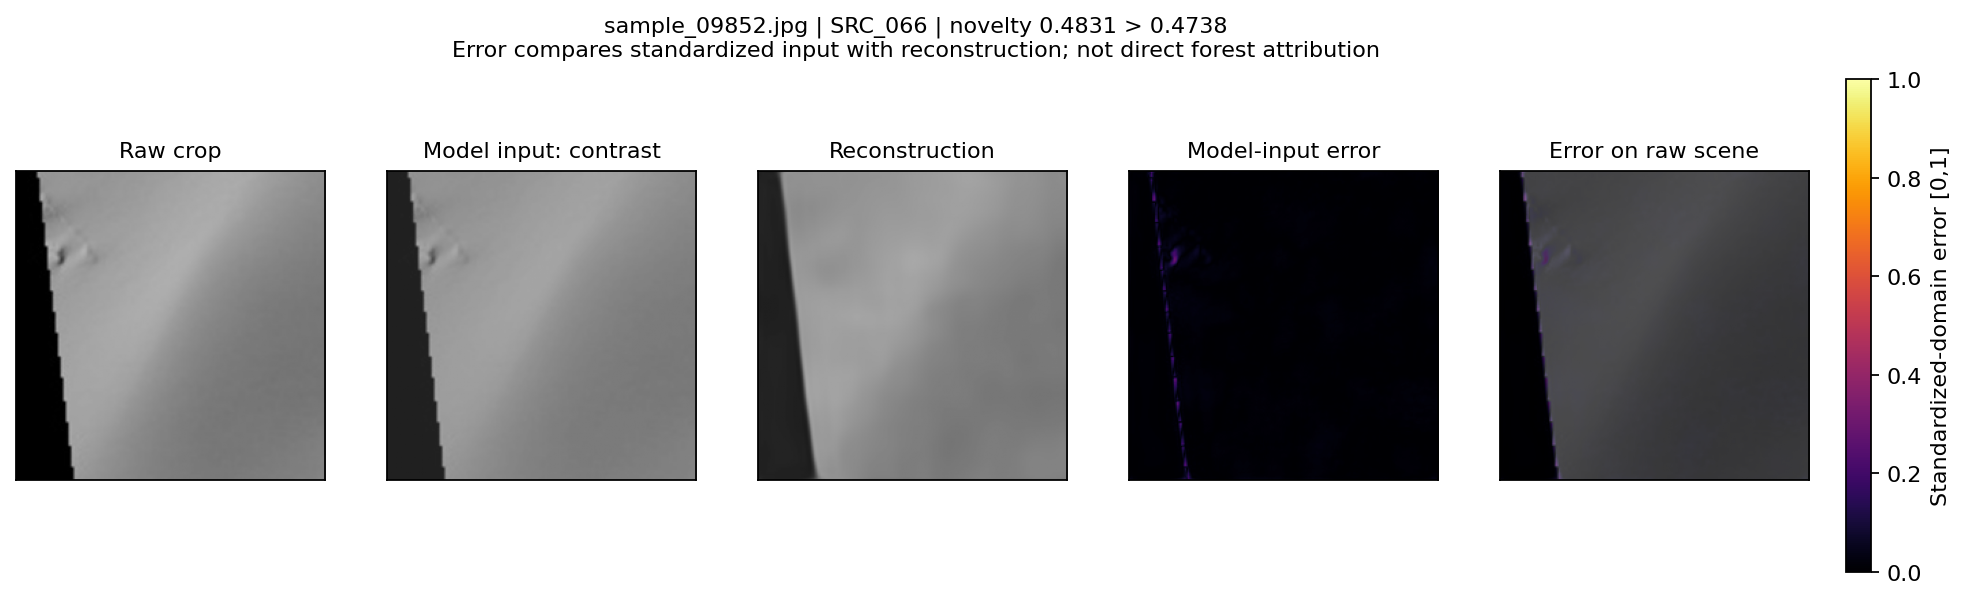

v5 : the same validation crop, shown after each independently calibrated selection


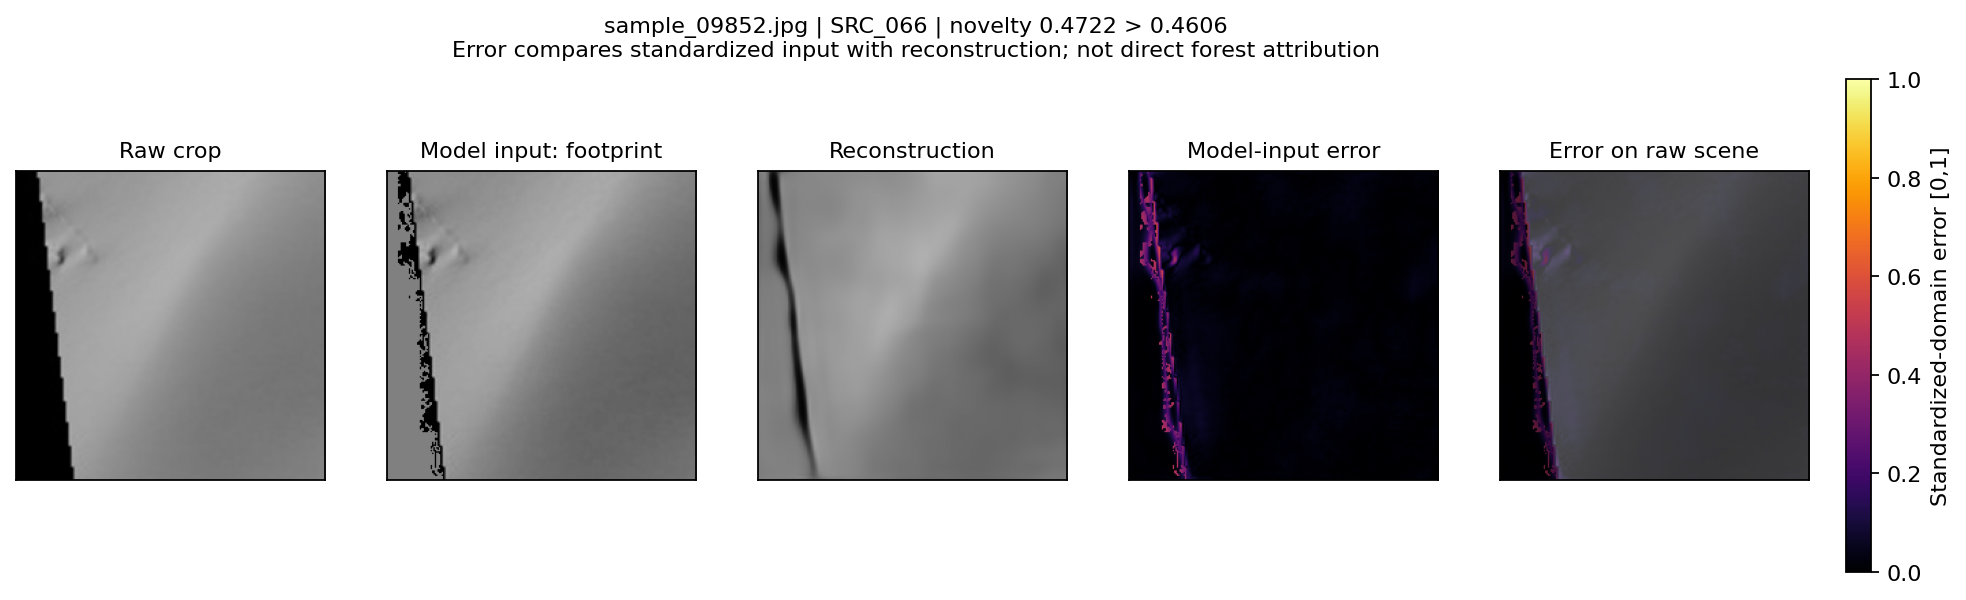

In [22]:
for name in ['v4','v5']:
    print(name,': the same validation crop, shown after each independently calibrated selection')
    recorded_example = ROOT/'outputs'/name/analysis_name/'heatmap_sample_09852.png'
    if recorded_example.exists():
        display(DisplayImage(filename=str(recorded_example)))
    else:
        print('This saved example is absent from the new run; inspect its own selected crops.')


## Phase 2.3 — Supplied metadata and source context
I use the organizer's crop-to-source index. I do not infer coordinates from appearance. Crop-weighted and equal-source rates differ because source sizes differ. These are descriptive summaries, not causal tests.

### Phase 2.4 — Optional metadata fusion
I keep metadata out of the score and do not claim the optional fusion credit.


In [23]:
display(pd.read_csv(ANALYSIS/'source_summary.csv').sort_values('flag_rate',ascending=False).head(15))
for field in ['season','resolution','longitude']:
    print(field)
    display(pd.read_csv(ANALYSIS/f'metadata_{field}.csv'))


,source_image_id,crops,flagged,mean_novelty,latitude,longitude,sun_angle,season,resolution,flag_rate
127,SRC_128,5,1,0.514460,90.0,0.0,56.634817,N-spring,0.50,0.200000
59,SRC_060,5,1,0.474967,90.0,0.0,64.124177,N-summer,0.25,0.200000
153,SRC_154,47,6,0.488782,0.0,180.0,54.770875,N-summer,0.50,0.127660
130,SRC_131,67,5,0.462993,10.0,180.0,60.540464,N-autumn,0.50,0.074627
37,SRC_038,55,1,0.449106,-15.0,180.0,32.097448,N-winter,0.25,0.018182
93,SRC_094,63,1,0.432850,20.0,180.0,66.934532,N-autumn,0.25,0.015873
103,SRC_104,66,1,0.462846,25.0,180.0,45.102036,N-summer,0.50,0.015152
110,SRC_111,137,1,0.446392,-35.0,180.0,79.069883,N-spring,1.00,0.007299
4,SRC_005,69,0,0.411808,0.0,180.0,55.846781,N-summer,0.50,0.000000
0,SRC_001,38,0,0.440004,-5.0,180.0,51.987197,N-spring,0.50,0.000000


season


,season,count,sum,mean,equal_source_mean_flag_rate
0,N-autumn,2181,6,0.002751,0.002919
1,N-spring,4190,2,0.000477,0.003637
2,N-summer,3030,8,0.002640,0.005810
3,N-winter,1021,1,0.000979,0.000727


resolution


,resolution,count,sum,mean,equal_source_mean_flag_rate
0,0.25,5326,3,0.000563,0.002147
1,0.50,4959,13,0.002621,0.006733
2,1.00,137,1,0.007299,0.007299


longitude


,longitude,count,sum,mean,equal_source_mean_flag_rate
0,0.0,704,2,0.002841,0.013793
1,180.0,9718,15,0.001544,0.001810


## Phase 3.1 — Inspecting the selected crops
I apply the threshold first and then select at most five eligible crops. I never lower it to force five.

For raw-input runs, error compares the original crop with its reconstruction. Standardized panels show the raw crop separately from the model input: their error compares standardized input with reconstruction. The overlay shows location, and is not direct attribution for Isolation Forest.


,filename,source_image_id,latitude,longitude,sun_angle,season,resolution,split,novelty_score,reconstruction_mse,flagged,threshold_bootstrap_flag_frequency
0,sample_07899.jpg,SRC_128,90.0,0.0,56.634817,N-spring,0.5,validation,0.566127,0.002053,True,1.0
1,sample_08288.jpg,SRC_154,0.0,180.0,54.770875,N-summer,0.5,train,0.557379,0.003085,True,1.0
2,sample_04609.jpg,SRC_131,10.0,180.0,60.540464,N-autumn,0.5,train,0.556367,0.000675,True,1.0
3,sample_00840.jpg,SRC_154,0.0,180.0,54.770875,N-summer,0.5,train,0.555589,0.000585,True,1.0
4,sample_05391.jpg,SRC_154,0.0,180.0,54.770875,N-summer,0.5,train,0.555249,0.000942,True,1.0


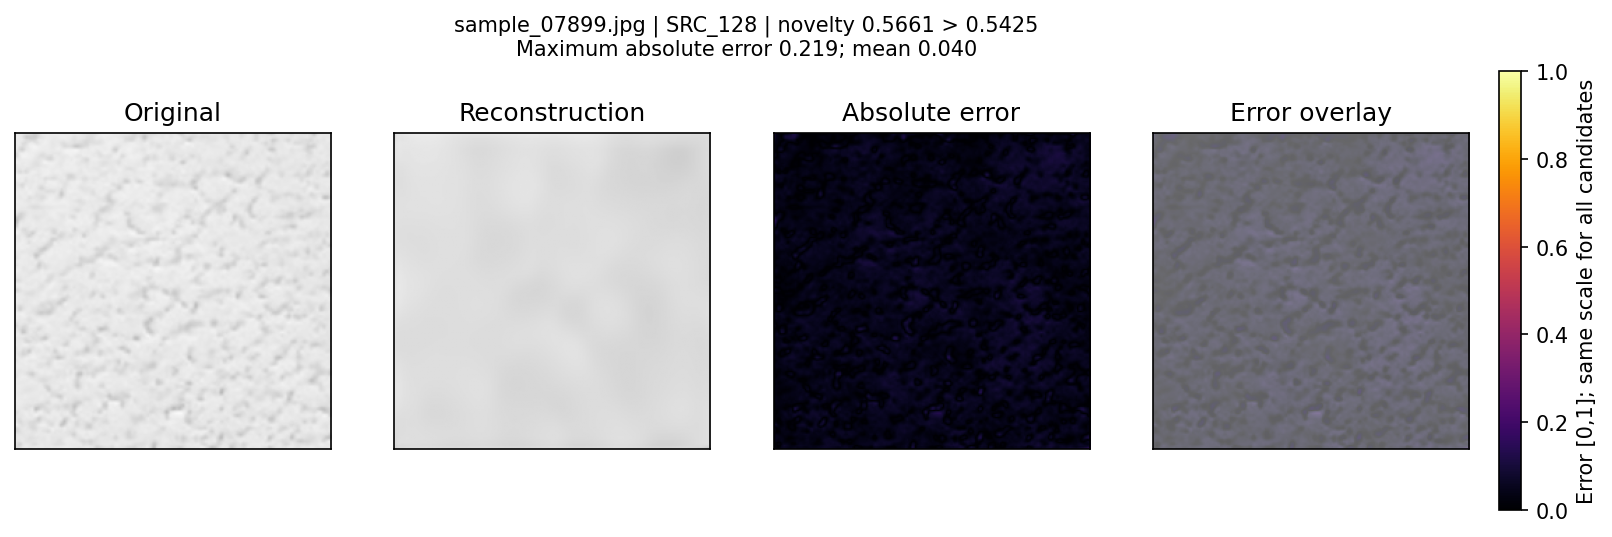

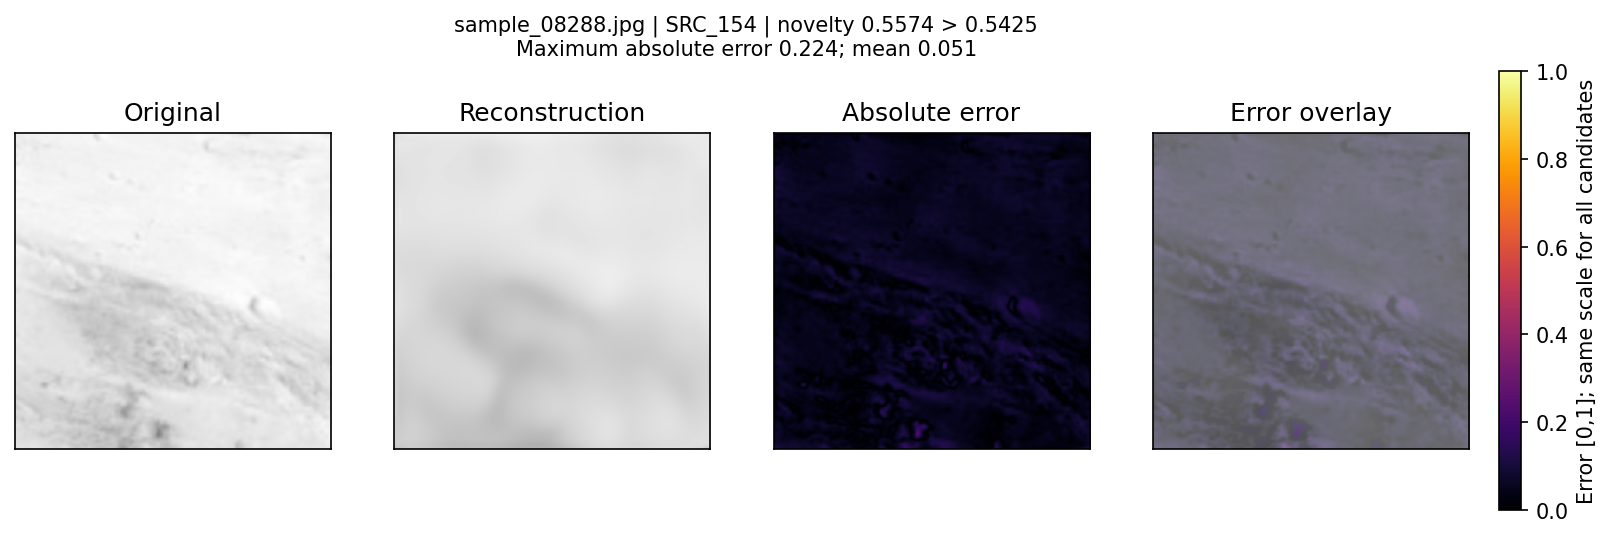

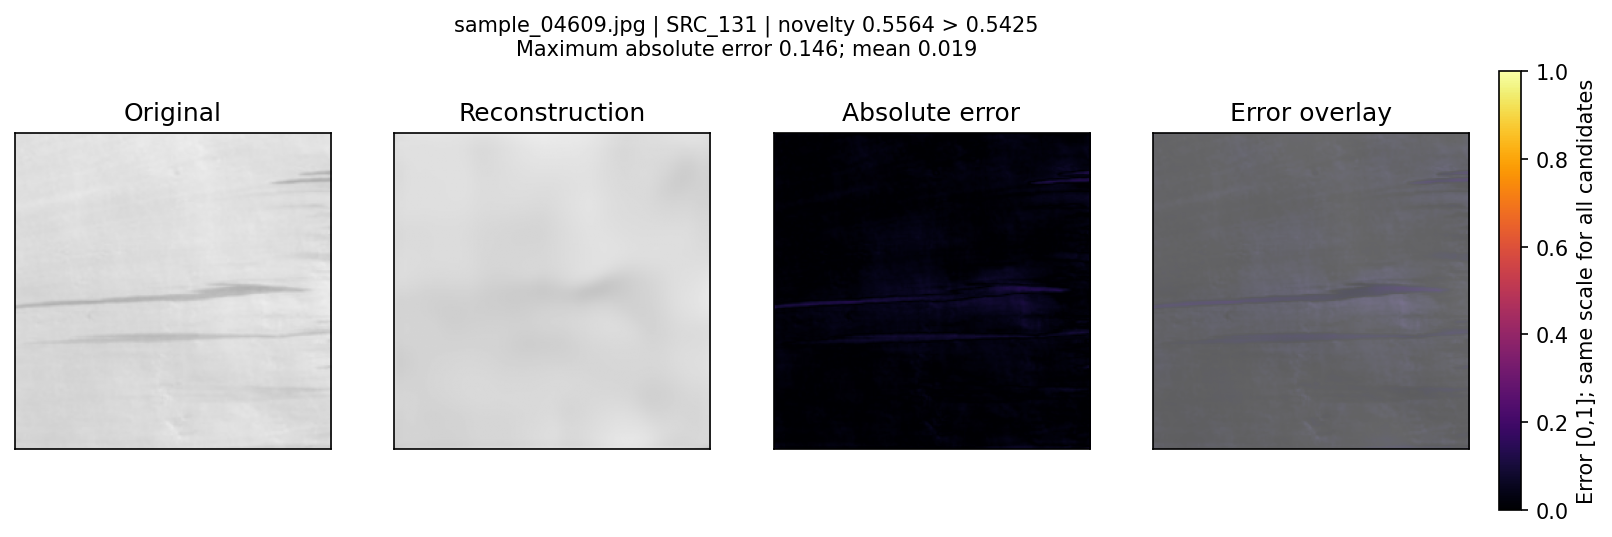

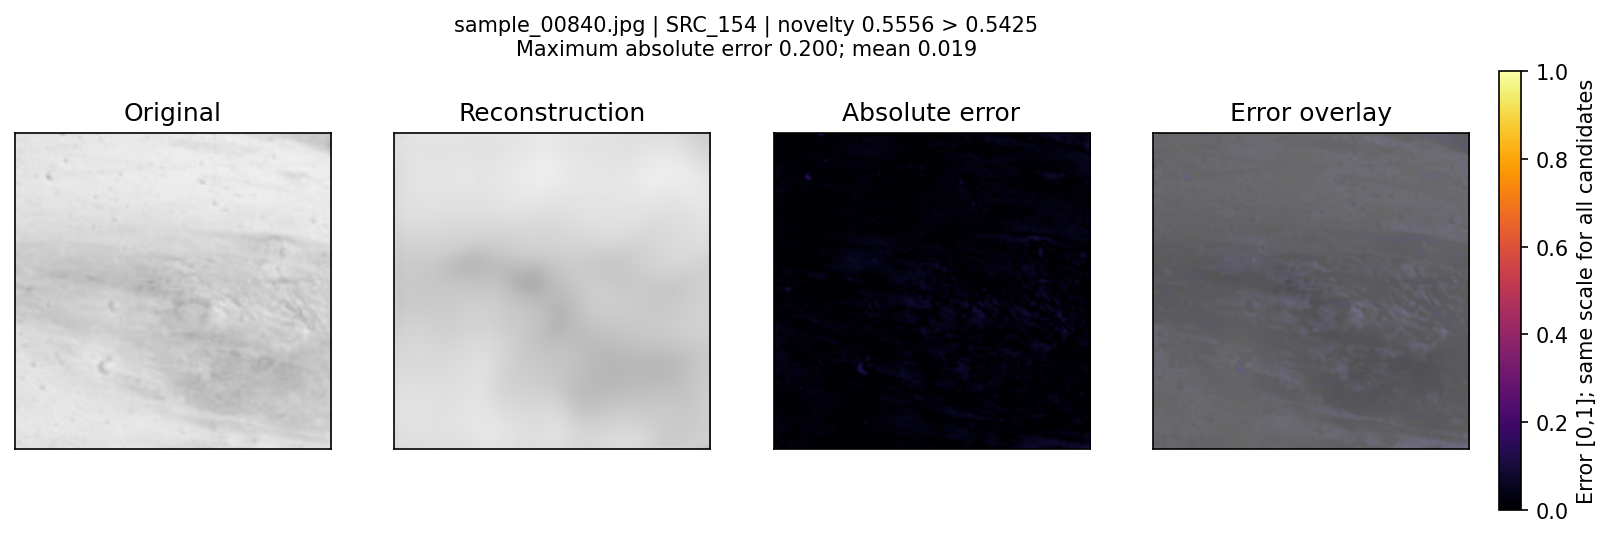

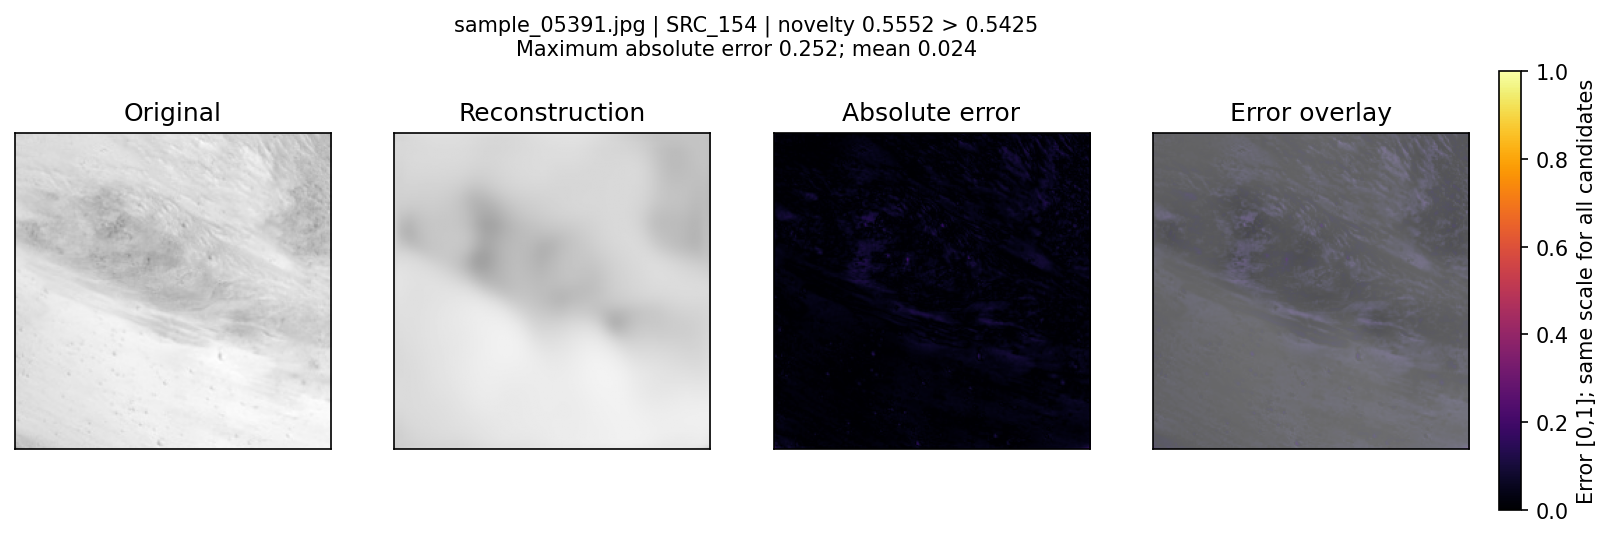

In [24]:
selected = pd.read_csv(ANALYSIS/'selected_for_interpretation.csv')
assert len(selected) <= 5 and (selected.novelty_score > calibration['threshold']).all()
display(selected)
for filename in selected.filename:
    display(DisplayImage(filename=str(ANALYSIS/f'heatmap_{Path(filename).stem}.png')))
if selected.empty:
    print('No crop passes the boundary. I do not manufacture a top-five list.')


### Do these exact candidates repeat?
I check the selected filenames against each run's own calibrated flags. This makes disagreement visible at the candidate level. A missing optional run is shown as unavailable rather than treated as a negative result. Agreement still does not establish a genuine anomaly.


In [25]:
candidate_checks = selected[['filename','source_image_id']].copy()
for name in ['v3','robust_seed','robust_split','v4','v5','improved_seed','improved_split']:
    score_file = ROOT/'outputs'/name/analysis_name/'novelty_scores.csv'
    if score_file.exists():
        other = pd.read_csv(score_file)
        eligible = set(other.loc[other.flagged,'filename'])
        candidate_checks[name] = candidate_checks.filename.isin(eligible)
    else:
        candidate_checks[name] = 'Unavailable'
display(candidate_checks)


,filename,source_image_id,v3,robust_seed,robust_split,v4,v5,improved_seed,improved_split
0,sample_07899.jpg,SRC_128,True,False,True,False,False,False,False
1,sample_08288.jpg,SRC_154,True,True,False,False,False,False,False
2,sample_04609.jpg,SRC_131,True,False,True,False,False,False,False
3,sample_00840.jpg,SRC_154,True,True,False,False,False,False,False
4,sample_05391.jpg,SRC_154,True,False,True,False,False,False,False


## Phase 3.2 — My physical interpretations
These notes describe the saved images I inspected. They remain hypotheses with alternatives. A new run that selects different crops needs a new visual review.


In [26]:
HYPOTHESES = {'sample_07899.jpg': {'evidence': 'A very bright crop with irregular, fine dark mottling '
                                  'across most of the image. The reconstruction retains '
                                  'broad brightness but loses the small-scale pattern. '
                                  'Error is distributed through that texture rather than '
                                  'concentrated on a single foreign object.',
                      'hypothesis': 'A bright surface mantle, potentially seasonal frost '
                                    'over textured polar terrain, is a plausible '
                                    'ordinary explanation. The supplied latitude of 90 '
                                    'and N-spring category are consistent with a '
                                    'polar-seasonal interpretation, if those coarse '
                                    'metadata values are representative.',
                      'alternative': 'Bright dust, exposure or contrast processing could '
                                     'also produce this appearance. A grayscale crop '
                                     'cannot establish ice composition, exact location '
                                     'or artificial insertion. The seasonal '
                                     'interpretation is a hypothesis, not a catalog '
                                     'identification.',
                      'reference': 'https://www.uahirise.org/PSP_007712_2670'},
 'sample_08288.jpg': {'evidence': 'A pale smooth upper region meets a darker, rougher '
                                  'diagonal band in the lower half. Small rounded marks '
                                  'and local texture remain visible. Reconstruction '
                                  'smooths the band, and the larger errors follow the '
                                  'rougher lower region.',
                      'hypothesis': 'A contact between a fine bright surface covering '
                                    'and rougher exposed terrain could explain the '
                                    'contrast. Wind redistribution of bright dust is one '
                                    'plausible surface process, without requiring '
                                    'unusual material.',
                      'alternative': 'Illumination across relief or image contrast '
                                     'processing could produce the same contrast. The '
                                     'isolated crop provides no reliable slope '
                                     'direction, physical scale or compositional '
                                     'evidence. Its high latent novelty does not '
                                     'establish a geological anomaly.',
                      'reference': 'https://www.jpl.nasa.gov/images/pia03789-cerberus-wind-streaks/'},
 'sample_04609.jpg': {'evidence': 'Several thin, nearly parallel dark streaks cross a '
                                  'bright, relatively smooth background; two long '
                                  'streaks dominate the middle. The decoder blurs the '
                                  'narrow lines, so the error map traces them even '
                                  'though average reconstruction error is low.',
                      'hypothesis': 'Wind-related removal or redistribution of a bright '
                                    'dust coating could expose darker streaks. This is '
                                    'an ordinary Martian process that can create strong '
                                    'directional contrast.',
                      'alternative': 'Shadows, image striping or another acquisition '
                                     'artifact remain possible. Orientation alone cannot '
                                     'distinguish a wind streak from these alternatives, '
                                     'and neither wind direction nor slope can be '
                                     'recovered reliably from this crop.',
                      'reference': 'https://www.jpl.nasa.gov/images/pia07132-wind-streaks-among-flows/'},
 'sample_00840.jpg': {'evidence': 'A bright background contains a broad diagonal '
                                  'textured band and scattered small rounded depressions '
                                  'or marks. Reconstruction preserves the diffuse band '
                                  'but removes many small details. Error follows the '
                                  'textured band and local marks.',
                      'hypothesis': 'Uneven bright dust cover over a rougher surface '
                                    'could produce this combination of smooth and '
                                    'textured patches. The marks may include small '
                                    'depressions, but their origin cannot be resolved '
                                    'here.',
                      'alternative': 'Shading or contrast processing could mimic '
                                     'material differences. This crop shares source '
                                     'SRC_154 with two other selected examples, so their '
                                     'similarity may reflect one acquisition rather than '
                                     'independent unusual geology.',
                      'reference': 'https://www.jpl.nasa.gov/images/pia03789-cerberus-wind-streaks/'},
 'sample_05391.jpg': {'evidence': 'A rough, striated upper region borders a brighter, '
                                  'smoother lower area along an oblique boundary. Fine '
                                  'linear textures dominate the upper part, and the '
                                  'reconstruction reduces them to broad smooth forms. '
                                  'The error map mainly follows that lost texture.',
                      'hypothesis': 'A transition between a dust-mantled surface and a '
                                    'more exposed textured substrate could explain the '
                                    'boundary. Wind erosion or deposition is a plausible '
                                    'process, but this image alone does not identify the '
                                    'landform.',
                      'alternative': 'Relief-dependent lighting or radiometric '
                                     'processing remains an alternative. Three of the '
                                     'five selected crops come from SRC_154; source '
                                     'conditions may influence the repeated selection. '
                                     'No injected object is confirmed by this panel.',
                      'reference': 'https://www.jpl.nasa.gov/images/pia03789-cerberus-wind-streaks/'}}
for filename in selected.filename:
    item = HYPOTHESES.get(filename)
    if item is None:
        display(Markdown('### '+filename+chr(10)+'New selection: visual review needed.'))
        continue
    parts = ['### '+filename,'**What I can see:** '+item['evidence'],
             '**Possible explanation:** '+item['hypothesis'],
             '**Alternative:** '+item['alternative']]
    if item.get('reference'):
        parts.append('[Process background; not a crop identification]('+item['reference']+')')
    display(Markdown((chr(10)*2).join(parts)))


### sample_07899.jpg

**What I can see:** A very bright crop with irregular, fine dark mottling across most of the image. The reconstruction retains broad brightness but loses the small-scale pattern. Error is distributed through that texture rather than concentrated on a single foreign object.

**Possible explanation:** A bright surface mantle, potentially seasonal frost over textured polar terrain, is a plausible ordinary explanation. The supplied latitude of 90 and N-spring category are consistent with a polar-seasonal interpretation, if those coarse metadata values are representative.

**Alternative:** Bright dust, exposure or contrast processing could also produce this appearance. A grayscale crop cannot establish ice composition, exact location or artificial insertion. The seasonal interpretation is a hypothesis, not a catalog identification.

[Process background; not a crop identification](https://www.uahirise.org/PSP_007712_2670)

### sample_08288.jpg

**What I can see:** A pale smooth upper region meets a darker, rougher diagonal band in the lower half. Small rounded marks and local texture remain visible. Reconstruction smooths the band, and the larger errors follow the rougher lower region.

**Possible explanation:** A contact between a fine bright surface covering and rougher exposed terrain could explain the contrast. Wind redistribution of bright dust is one plausible surface process, without requiring unusual material.

**Alternative:** Illumination across relief or image contrast processing could produce the same contrast. The isolated crop provides no reliable slope direction, physical scale or compositional evidence. Its high latent novelty does not establish a geological anomaly.

[Process background; not a crop identification](https://www.jpl.nasa.gov/images/pia03789-cerberus-wind-streaks/)

### sample_04609.jpg

**What I can see:** Several thin, nearly parallel dark streaks cross a bright, relatively smooth background; two long streaks dominate the middle. The decoder blurs the narrow lines, so the error map traces them even though average reconstruction error is low.

**Possible explanation:** Wind-related removal or redistribution of a bright dust coating could expose darker streaks. This is an ordinary Martian process that can create strong directional contrast.

**Alternative:** Shadows, image striping or another acquisition artifact remain possible. Orientation alone cannot distinguish a wind streak from these alternatives, and neither wind direction nor slope can be recovered reliably from this crop.

[Process background; not a crop identification](https://www.jpl.nasa.gov/images/pia07132-wind-streaks-among-flows/)

### sample_00840.jpg

**What I can see:** A bright background contains a broad diagonal textured band and scattered small rounded depressions or marks. Reconstruction preserves the diffuse band but removes many small details. Error follows the textured band and local marks.

**Possible explanation:** Uneven bright dust cover over a rougher surface could produce this combination of smooth and textured patches. The marks may include small depressions, but their origin cannot be resolved here.

**Alternative:** Shading or contrast processing could mimic material differences. This crop shares source SRC_154 with two other selected examples, so their similarity may reflect one acquisition rather than independent unusual geology.

[Process background; not a crop identification](https://www.jpl.nasa.gov/images/pia03789-cerberus-wind-streaks/)

### sample_05391.jpg

**What I can see:** A rough, striated upper region borders a brighter, smoother lower area along an oblique boundary. Fine linear textures dominate the upper part, and the reconstruction reduces them to broad smooth forms. The error map mainly follows that lost texture.

**Possible explanation:** A transition between a dust-mantled surface and a more exposed textured substrate could explain the boundary. Wind erosion or deposition is a plausible process, but this image alone does not identify the landform.

**Alternative:** Relief-dependent lighting or radiometric processing remains an alternative. Three of the five selected crops come from SRC_154; source conditions may influence the repeated selection. No injected object is confirmed by this panel.

[Process background; not a crop identification](https://www.jpl.nasa.gov/images/pia03789-cerberus-wind-streaks/)

## Phase 4 — What happened in my experiments

### v1: I established a baseline

I trained a 128-dimensional MSE autoencoder from random initialization. Fine texture was smoothed even though validation MSE reached 0.002694. I used that observation to motivate a loss change.

### v2 and v3: I changed one factor at a time

Adding SSIM raised validation SSIM from 0.6611 to 0.6717, with a small MSE cost. Increasing the latent vector to 256 then gave MSE 0.002599 and SSIM 0.6738. That is a reconstruction gain, not a hidden-label accuracy result.

### I corrected the threshold and checked repetition

The adjusted-boxplot cutoff exceeded every v1 score. I retained that failure, inspected the multimodal distribution, and adopted the fixed mixture-envelope rule with whole-source bootstrap uncertainty. A controlled increase from 400 to 2,000 trees improved forest repeatability. Independent training then exposed fragile candidate membership and a bright-image concentration.

### v4: I tested brightness normalization

I standardized each crop without fitting dataset-level statistics. The controlled brightness response improved by 91.4% at the 95th percentile, and the median brightness percentile of the five selected crops fell from 99.90 to 47.51. Forest repeatability weakened and all five contained black strips or borders. I recorded both outcomes.

### v5: I tested an exact-zero footprint heuristic

I excluded border-connected exact zeros from normalization statistics and filled them with 0.5. The controlled brightness response improved by 99.87% relative to v3, but minimum forest Jaccard fell to 0.227. Near-black edge fragments remained. I did not silently broaden the mask after seeing selected examples.

### I repeated the stronger standardized variant

For v4, changing initialization gives flag-set Jaccard 0.207 and full-ranking correlation 0.867; changing the source split gives 0.360 and 0.866. The three contrast runs flag 24, 11 and 10 crops, with 4 in their intersection. On 1,253 crops held out from both source partitions, rank correlation is 0.897. For raw v3, the corresponding initialization/split Jaccards remain 0.150/0.294, with zero crops flagged in all three raw runs. These are limited sensitivity checks, not detection accuracy. Initialization repeats change both encoder and forest seeds; separate forest-only repeats isolate detector randomness.

### I recovered interrupted runs and retained the evidence

Concurrent processes encountered a paging-file error and temporary-checkpoint write failures. I verified the existing checkpoints, removed only the failed temporary files and resumed with unchanged configurations. I then ran GPU work sequentially and used reversible filesystem compression to recover space. The saved execution is local, although the notebook is prepared for Colab.

### My final decision

I retain v3 as the screening reference. v4 and v5 reduce a specified brightness nuisance, but their minimum forest-seed flag overlaps fall from 0.667 for v3 to 0.467 and 0.227. All five leading v4 examples contain conspicuous black strips or borders, and the v5 exact-zero mask leaves near-black edge fragments. That evidence does not support replacing the reference with a more reliable geological detector. v3 itself remains brightness-confounded and unstable across independent training runs; I do not present its candidates as confirmed anomalies.

## What I would test next
I would test more independent source partitions and longer learning curves under a fixed budget. I would also check whether normalization hides real albedo anomalies. Appearance alone cannot decide that; organizer-held labels would be needed for precision and recall.

## Sources
- [SSIM author resource](https://www.cns.nyu.edu/~lcv/ssim/)
- [Resize-convolution](https://distill.pub/2016/deconv-checkerboard/)
- [Isolation Forest](https://scikit-learn.org/stable/modules/generated/sklearn.ensemble.IsolationForest.html)
- [Gaussian mixture selection](https://scikit-learn.org/stable/auto_examples/mixture/plot_gmm_selection.html)
- [Connected-region labelling](https://docs.scipy.org/doc/scipy/reference/generated/scipy.ndimage.label.html)

The constraints come from the three supplied competition documents. My decision log preserves failed approaches and verification. Team details and private repository access remain submission logistics.
